In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import linregress
import glob
import cftime
valid_combinations = [
    (1, 1), (1, 2), (1, 1000),  # r1i1p1f1, r1i2p1f1, r1i1000p1f1
    (2, 1),                     # r2i1p1f1
    (3, 1),                     # r3i1p1f1
    (4, 1),                     # r4i1p1f1
    (5, 1),                     # r5i1p1f1
    (6, 1),                     # r6i1p1f1
    (7, 1),                     # r7i1p1f1
    (8, 1),                     # r8i1p1f1
    (9, 1),                     # r9i1p1f1
    (10, 1)                     # r10i1p1f1
]

# Generate file paths only for valid combinations
files_historical = [
    f'E:/Jubjang/FWIminimumRH/fwisa_ann_MRI-ESM2-0_historical_r{i}i{j}p1f1_g025.nc'
    for i, j in valid_combinations
]
file_SSP119 = [f'E:/Jubjang/FWIminimumRH/fwisa_ann_MRI-ESM2-0_ssp119_r{i}i1p1f1_g025.nc'for i in range(1, 6)]
files_SSP126 = [f'E:/Jubjang/FWIminimumRH/fwisa_ann_MRI-ESM2-0_ssp126_r{i}i1p1f1_g025.nc' for i in range(1, 6)]
#missingi3
files_SSP245 = [f'E:/Jubjang/FWIminimumRH/fwisa_ann_MRI-ESM2-0_ssp245_r{i}i1p1f1_g025.nc' for i in range(1, 6)]
files_SSP370 = [f'E:/Jubjang/FWIminimumRH/fwisa_ann_MRI-ESM2-0_ssp370_r{i}i1p1f1_g025.nc' for i in range(1, 6)]
# file_SSP434 = 'D:/Jubjang/FWIminimumRH/fwisa_ann_MRI-ESM2-0_ssp434_r1i1p1f1_g025.nc'
file_SSP460 = 'E:/Jubjang/FWIminimumRH/fwisa_ann_MRI-ESM2-0_ssp460_r1i1p1f1_g025.nc'
file_SSP534 = 'E:/Jubjang/FWIminimumRH/fwisa_ann_MRI-ESM2-0_ssp534-over_r1i1p1f1_g025.nc'
valid_combinations_ssp585 = [
    (1, 1), (1, 2),  # r1i1p1f1, r1i2p1f1
    (2, 1),          # r2i1p1f1
    (3, 1),          # r3i1p1f1
    (4, 1),          # r4i1p1f1
    (5, 1)           # r5i1p1f1
]

# Generate file paths only for the valid combinations
files_SSP585 = [
    f'E:/Jubjang/FWIminimumRH/fwisa_ann_MRI-ESM2-0_ssp585_r{i}i{j}p1f1_g025.nc'
    for i, j in valid_combinations_ssp585
]

# Function to load datasets from a list of file paths
# def load_datasets(file_list):
#     datasets = []
#     for file in file_list:
#         try:
#             ds = xr.open_dataset(file)
#             datasets.append(ds)
#         except Exception as e:
#             print(f"Error loading {file}: {e}")
#     return datasets
def load_datasets(file_list):
    return [xr.open_mfdataset(file, combine='by_coords', engine='netcdf4') for file in file_list]

# Load datasets
datasets_historical = load_datasets(files_historical)
datasets_SSP119 = load_datasets(file_SSP119)
datasets_SSP126 = load_datasets(files_SSP126)
datasets_SSP245 = load_datasets(files_SSP245)
datasets_SSP370 = load_datasets(files_SSP370)
# dataset_SSP434 = xr.open_mfdataset(file_SSP434, combine='by_coords', engine='netcdf4')
datasets_SSP460 = xr.open_mfdataset(file_SSP460, combine='by_coords', engine='netcdf4')
datasets_SSP534 = xr.open_mfdataset(file_SSP534, combine='by_coords', engine='netcdf4')
datasets_SSP585 = load_datasets(files_SSP585)

print("Datasets successfully loaded!")

Datasets successfully loaded!


In [2]:
# Function to concatenate ensemble members
def concatenate_ensemble(datasets_list):
    """Concatenates a list of xarray datasets along the 'ensemble' dimension."""
    return xr.concat(datasets_list, dim="ensemble")

# Concatenating historical datasets
datasets_historical = concatenate_ensemble(datasets_historical)

# Concatenating SSP datasets
datasets_SSP119 = concatenate_ensemble(datasets_SSP119)
datasets_SSP126 = concatenate_ensemble(datasets_SSP126)
datasets_SSP245 = concatenate_ensemble(datasets_SSP245)
datasets_SSP370 = concatenate_ensemble(datasets_SSP370)
datasets_SSP585 = concatenate_ensemble(datasets_SSP585)

# Wrapping single scenario datasets into lists before concatenation
datasets_SSP460 = [datasets_SSP460]  # Wrap it in a list to match other datasets
datasets_SSP534 = [datasets_SSP534]  # Wrap it in a list to match other datasets

# Concatenate SSP460 and SSP534 as well
datasets_SSP460 = concatenate_ensemble(datasets_SSP460)
datasets_SSP534 = concatenate_ensemble(datasets_SSP534)

print("Datasets successfully concatenated along the 'ensemble' dimension!")


Datasets successfully concatenated along the 'ensemble' dimension!


In [3]:
# Group datasets and labels
datasets_all_scenarios = [
    datasets_historical,
    datasets_SSP119,
    datasets_SSP126,
    datasets_SSP245,
    datasets_SSP370,
    # [dataset_SSP434] +
    [datasets_SSP460],
    [datasets_SSP534],
    datasets_SSP585
]

labels_all_scenarios = (
    ['Historical to Present (1850-2015)'] +
    ['SSP1-1.9 ("Very Low Emissions")'] +  
    ['SSP1-2.6 ("Low Emissions with Strong Mitigation")'] +
    ['SSP2-4.5 ("Middle of the Road")'] +
    ['SSP3-7.0 ("Regional Rivalry")'] +
    ['SSP4-6.0 ("Inequality and Regional Development")'] +  # Added SSP4-6.0
    ['SSP5-3.4 ("Fossil-Fueled Development with Delayed Climate Action")'] +
    ['SSP5-3.4-over ("Delayed Climate Action - Overshoot")'] +  # Added SSP5-3.4-over
    ['SSP5-8.5 ("Fossil-Fueled Development with No Climate Action")']
)

In [4]:
# Define CFDatetimeCoder
time_coder = xr.coding.times.CFDatetimeCoder(use_cftime=True)

# Function to load datasets
def load_datasets(file_list):
    return [xr.open_mfdataset(file, combine='by_coords', engine='netcdf4', decode_times=time_coder) for file in file_list]

# Generate file paths
files_pr_historical = [
    f'E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_historical_r{i}i{j}p1f1_gn_185001-201412.nc'
    for i, j in valid_combinations
]
files_pr_SSP119_r1 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp119_r1i1p1f1_gn_*.nc"))
files_pr_SSP119_r2 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp119_r2i1p1f1_gn_*.nc"))
files_pr_SSP119_r3 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp119_r3i1p1f1_gn_*.nc"))
files_pr_SSP119_r4 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp119_r4i1p1f1_gn_*.nc"))
files_pr_SSP119_r5 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp119_r5i1p1f1_gn_*.nc"))

files_pr_SSP126_r1 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp126_r1i1p1f1_gn_*.nc"))
files_pr_SSP126_r2 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp126_r2i1p1f1_gn_*.nc"))
files_pr_SSP126_r3 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp126_r3i1p1f1_gn_*.nc"))
files_pr_SSP126_r4 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp126_r4i1p1f1_gn_*.nc"))
files_pr_SSP126_r5 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp126_r5i1p1f1_gn_*.nc"))

files_pr_SSP245_r1 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp245_r1i1p1f1_gn*.nc"))
files_pr_SSP245_r2 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp245_r2i1p1f1_gn_*.nc"))
files_pr_SSP245_r3 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp245_r3i1p1f1_gn_*.nc"))
files_pr_SSP245_r4 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp245_r4i1p1f1_gn_*.nc"))
files_pr_SSP245_r5 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp245_r5i1p1f1_gn_*.nc"))

files_pr_SSP370 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp370_r*i1p1f1_gn_*.nc"))
file_pr_SSP460 = 'E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp460_r1i1p1f1_gn_*.nc'
files_pr_SSP534_r1 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp534-over_r1i1p1f1_gn*.nc"))

files_pr_SSP585_r1i1 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp585_r1i1p1f1_gn*.nc"))
files_pr_SSP585_r1i2 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp585_r1i2p1f1_gn*.nc"))
files_pr_SSP585_r2 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp585_r2i1p1f1_gn*.nc"))
files_pr_SSP585_r3 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp585_r3i1p1f1_gn*.nc"))
files_pr_SSP585_r4 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp585_r4i1p1f1_gn*.nc"))
files_pr_SSP585_r5 = sorted(glob.glob("E:/Jubjang/pr/pr_Amon_MRI-ESM2-0_ssp585_r5i1p1f1_gn*.nc"))

# Load datasets
datasets_pr_historical = load_datasets(files_pr_historical)
datasets_pr_SSP460 = xr.open_mfdataset(file_pr_SSP460, combine='by_coords', engine='netcdf4')
datasets_pr_SSP245 = xr.concat(
    [
        xr.open_mfdataset(files_pr_SSP245_r1, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_pr_SSP245_r2, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_pr_SSP245_r3, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_pr_SSP245_r4, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_pr_SSP245_r5, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
    ],
    dim="ensemble"
)

datasets_pr_SSP119 = xr.concat(
    [
        xr.open_mfdataset(files_pr_SSP119_r1, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_pr_SSP119_r2, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_pr_SSP119_r3, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_pr_SSP119_r4, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_pr_SSP119_r5, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
    ],
    dim="ensemble"
)

datasets_pr_SSP126 = xr.concat(
    [
        xr.open_mfdataset(files_pr_SSP126_r1, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_pr_SSP126_r2, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_pr_SSP126_r3, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_pr_SSP126_r4, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_pr_SSP126_r5, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
    ],
    dim="ensemble"
)

datasets_pr_SSP370 = xr.concat(
    [xr.open_dataset(file, decode_times=time_coder).assign_coords(ensemble=i) for i, file in enumerate(files_pr_SSP370)],
    dim="ensemble"
)

datasets_pr_SSP534 = xr.open_mfdataset(files_pr_SSP534_r1, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})

datasets_pr_SSP585 = xr.concat(
    [
        xr.open_mfdataset(files_pr_SSP585_r1i1, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_pr_SSP585_r1i2, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_pr_SSP585_r2, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_pr_SSP585_r3, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_pr_SSP585_r4, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_pr_SSP585_r5, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
    ],
    dim="ensemble"
)


In [5]:
datasets_pr_historical = xr.concat(datasets_pr_historical, dim="ensemble")
datasets_pr_all_scenarios = [
    datasets_pr_historical,
    datasets_pr_SSP119,
    datasets_pr_SSP126,
    datasets_pr_SSP245,
    datasets_pr_SSP370,
    datasets_pr_SSP460,
    datasets_pr_SSP534,
    datasets_pr_SSP585
]

In [6]:
# Define CFDatetimeCoder for proper time decoding
time_coder = xr.coding.times.CFDatetimeCoder(use_cftime=True)

# Function to load datasets with proper time decoding
def load_datasets(file_list):
    return [xr.open_mfdataset(file, combine='by_coords', engine='netcdf4', decode_times=time_coder) for file in file_list]

# Generate file paths for tasmax
files_tasmax_historical = [
    f'E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_historical_r{i}i{j}p1f1_gn_185001-201412.nc'
    for i, j in valid_combinations
]
files_tasmax_SSP119_r1 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp119_r1i1p1f1_gn_*.nc"))
files_tasmax_SSP119_r2 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp119_r2i1p1f1_gn_*.nc"))
files_tasmax_SSP119_r3 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp119_r3i1p1f1_gn_*.nc"))
files_tasmax_SSP119_r4 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp119_r4i1p1f1_gn_*.nc"))
files_tasmax_SSP119_r5 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp119_r5i1p1f1_gn_*.nc"))

files_tasmax_SSP126_r1 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp126_r1i1p1f1_gn_*.nc"))
files_tasmax_SSP126_r2 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp126_r2i1p1f1_gn_*.nc"))
files_tasmax_SSP126_r3 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp126_r3i1p1f1_gn_*.nc"))
files_tasmax_SSP126_r4 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp126_r4i1p1f1_gn_*.nc"))
files_tasmax_SSP126_r5 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp126_r5i1p1f1_gn_*.nc"))

files_tasmax_SSP245_r1 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp245_r1i1p1f1_gn*.nc"))
files_tasmax_SSP245_r2 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp245_r2i1p1f1_gn_*.nc"))
files_tasmax_SSP245_r3 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp245_r3i1p1f1_gn_*.nc"))
files_tasmax_SSP245_r4 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp245_r4i1p1f1_gn_*.nc"))
files_tasmax_SSP245_r5 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp245_r5i1p1f1_gn_*.nc"))

files_tasmax_SSP370 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp370_r*i1p1f1_gn_*.nc"))
files_tasmax_SSP534 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp534-over_r*i1p1f1_gn*.nc"))
files_tasmax_SSP460 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp460_r1i1p1f1_gn*.nc"))
files_tasmax_SSP585_r1i1 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp585_r1i1p1f1_gn*.nc"))
files_tasmax_SSP585_r1i2 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp585_r1i2p1f1_gn*.nc"))
files_tasmax_SSP585_r2 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp585_r2i1p1f1_gn*.nc"))
files_tasmax_SSP585_r3 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp585_r3i1p1f1_gn*.nc"))
files_tasmax_SSP585_r4 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp585_r4i1p1f1_gn*.nc"))
files_tasmax_SSP585_r5 = sorted(glob.glob("E:/Jubjang/tasmax/tasmax_Amon_MRI-ESM2-0_ssp585_r5i1p1f1_gn*.nc"))

# Load datasets
datasets_tasmax_historical = load_datasets(files_tasmax_historical)
datasets_tasmax_SSP119 = xr.concat(
    [
        xr.open_mfdataset(files_tasmax_SSP119_r1, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_tasmax_SSP119_r2, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_tasmax_SSP119_r3, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_tasmax_SSP119_r4, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_tasmax_SSP119_r5, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
    ],
    dim="ensemble"
)
datasets_tasmax_SSP245 = xr.concat(
    [
        xr.open_mfdataset(files_tasmax_SSP245_r1, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_tasmax_SSP245_r2, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_tasmax_SSP245_r3, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_tasmax_SSP245_r4, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_tasmax_SSP245_r5, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
    ],
    dim="ensemble"
)

datasets_tasmax_SSP126 = xr.concat(
    [
        xr.open_mfdataset(files_tasmax_SSP126_r1, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_tasmax_SSP126_r2, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_tasmax_SSP126_r3, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_tasmax_SSP126_r4, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_tasmax_SSP126_r5, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
    ],
    dim="ensemble"
)

datasets_tasmax_SSP370 = xr.concat(
    [xr.open_dataset(file, decode_times=time_coder).assign_coords(ensemble=i) for i, file in enumerate(files_tasmax_SSP370)],
    dim="ensemble"
)

datasets_tasmax_SSP534 = xr.open_mfdataset(files_tasmax_SSP534, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_tasmax_SSP460 = xr.open_mfdataset(files_tasmax_SSP460, combine="by_coords", engine="netcdf4", decode_times=time_coder, chunks={'time': 100})
datasets_tasmax_SSP585 = xr.concat(
    [
        xr.open_mfdataset(files_tasmax_SSP585_r1i1, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_tasmax_SSP585_r1i2, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_tasmax_SSP585_r2, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_tasmax_SSP585_r3, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_tasmax_SSP585_r4, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_tasmax_SSP585_r5, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
    ],
    dim="ensemble"
)
datasets_tasmax_historical = xr.concat(datasets_tasmax_historical, dim="ensemble")

In [7]:
# Define CFDatetimeCoder for proper time decoding
time_coder = xr.coding.times.CFDatetimeCoder(use_cftime=True)

# Function to load datasets with proper time decoding
def load_datasets(file_list):
    return [xr.open_mfdataset(file, combine='by_coords', engine='netcdf4', decode_times=time_coder) for file in file_list]

# Generate file paths for sfcWind
files_sfcWind_historical = [
    f'E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_historical_r{i}i{j}p1f1_gn_185001-201412.nc'
    for i, j in valid_combinations
]

files_sfcWind_SSP119_r1 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp119_r1i1p1f1_gn_*.nc"))
files_sfcWind_SSP119_r2 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp119_r2i1p1f1_gn_*.nc"))
files_sfcWind_SSP119_r3 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp119_r3i1p1f1_gn_*.nc"))
files_sfcWind_SSP119_r4 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp119_r4i1p1f1_gn_*.nc"))
files_sfcWind_SSP119_r5 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp119_r5i1p1f1_gn_*.nc"))

files_sfcWind_SSP126_r1 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp126_r1i1p1f1_gn_*.nc"))
files_sfcWind_SSP126_r2 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp126_r2i1p1f1_gn_*.nc"))
files_sfcWind_SSP126_r3 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp126_r3i1p1f1_gn_*.nc"))
files_sfcWind_SSP126_r4 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp126_r4i1p1f1_gn_*.nc"))
files_sfcWind_SSP126_r5 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp126_r5i1p1f1_gn_*.nc"))

files_sfcWind_SSP245_r1 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp245_r1i1p1f1_gn*.nc"))
files_sfcWind_SSP245_r2 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp245_r2i1p1f1_gn_*.nc"))
files_sfcWind_SSP245_r3 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp245_r3i1p1f1_gn_*.nc"))
files_sfcWind_SSP245_r4 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp245_r4i1p1f1_gn_*.nc"))
files_sfcWind_SSP245_r5 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp245_r5i1p1f1_gn_*.nc"))
file_sfcWind_SSP460 = 'E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp460_r1i1p1f1_gn_*.nc'
files_sfcWind_SSP370 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp370_r*i1p1f1_gn_*.nc"))
files_sfcWind_SSP534_r1 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp534-over_r1i1p1f1_gn*.nc"))

files_sfcWind_SSP585_r1i1 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp585_r1i1p1f1_gn_*.nc"))
files_sfcWind_SSP585_r1i2 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp585_r1i2p1f1_gn_201501-210012.nc"))
files_sfcWind_SSP585_r2 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp585_r2i1p1f1_gn*.nc"))
files_sfcWind_SSP585_r3 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp585_r3i1p1f1_gn*.nc"))
files_sfcWind_SSP585_r4 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp585_r4i1p1f1_gn*.nc"))
files_sfcWind_SSP585_r5 = sorted(glob.glob("E:/Jubjang/sfcWind/sfcWind_Amon_MRI-ESM2-0_ssp585_r5i1p1f1_gn*.nc"))

# Load datasets
datasets_sfcWind_historical = load_datasets(files_sfcWind_historical)

datasets_sfcWind_SSP460 = xr.open_mfdataset(file_sfcWind_SSP460, combine='by_coords', engine='netcdf4', decode_times=time_coder)
datasets_sfcWind_SSP245 = xr.concat(
    [
        xr.open_mfdataset(files_sfcWind_SSP245_r1, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_sfcWind_SSP245_r2, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_sfcWind_SSP245_r3, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_sfcWind_SSP245_r4, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_sfcWind_SSP245_r5, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
    ],
    dim="ensemble"
)
datasets_sfcWind_SSP119 = xr.concat(
    [
        xr.open_mfdataset(files_sfcWind_SSP119_r1, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_sfcWind_SSP119_r2, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_sfcWind_SSP119_r3, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_sfcWind_SSP119_r4, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_sfcWind_SSP119_r5, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
    ],
    dim="ensemble"
)

datasets_sfcWind_SSP126 = xr.concat(
    [
        xr.open_mfdataset(files_sfcWind_SSP126_r1, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_sfcWind_SSP126_r2, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_sfcWind_SSP126_r3, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_sfcWind_SSP126_r4, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_sfcWind_SSP126_r5, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
    ],
    dim="ensemble"
)

datasets_sfcWind_SSP370 = xr.concat(
    [xr.open_dataset(file, decode_times=time_coder).assign_coords(ensemble=i) for i, file in enumerate(files_sfcWind_SSP370)],
    dim="ensemble"
)

datasets_sfcWind_SSP534 = xr.open_mfdataset(files_sfcWind_SSP534_r1, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})

datasets_sfcWind_SSP585 = xr.concat(
    [
        xr.open_mfdataset(files_sfcWind_SSP585_r1i1, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_sfcWind_SSP585_r1i2, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_sfcWind_SSP585_r2, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_sfcWind_SSP585_r3, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_sfcWind_SSP585_r4, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_sfcWind_SSP585_r5, combine="by_coords", decode_times=time_coder, chunks={'time': 100}),
    ],
    dim="ensemble"
)


In [8]:
datasets_sfcWind_historical = xr.concat(datasets_sfcWind_historical, dim="ensemble")
datasets_sfcWind_all_scenarios = [
    datasets_sfcWind_historical,
    datasets_sfcWind_SSP119,
    datasets_sfcWind_SSP126,
    datasets_sfcWind_SSP245,
    datasets_sfcWind_SSP370,
    datasets_sfcWind_SSP460,
    datasets_sfcWind_SSP534,
    datasets_sfcWind_SSP585
]


In [9]:
# Generate file paths for hursmin
files_hursmin_historical_r1i1 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_historical_r1i1p1f1_gn_*.nc"))
files_hursmin_historical_r1i2 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_historical_r1i2p1f1_gn_*.nc"))
files_hursmin_historical_r1i1000 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_historical_r1i1000p1f1_gn_*.nc"))
files_hursmin_historical_r2 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_historical_r2i1p1f1_gn_*.nc"))
files_hursmin_historical_r3 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_historical_r3i1p1f1_gn_*.nc"))
files_hursmin_historical_r4 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_historical_r4i1p1f1_gn_*.nc"))
files_hursmin_historical_r5 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_historical_r5i1p1f1_gn_*.nc"))
files_hursmin_historical_r6 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_historical_r6i1p1f1_gn_*.nc"))
files_hursmin_historical_r7 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_historical_r7i1p1f1_gn_*.nc"))
files_hursmin_historical_r8 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_historical_r8i1p1f1_gn_*.nc"))
files_hursmin_historical_r9 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_historical_r9i1p1f1_gn_*.nc"))
files_hursmin_historical_r10 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_historical_r10i1p1f1_gn_*.nc"))

files_hursmin_SSP119_r1 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_ssp119_r1i1p1f1_gn_*.nc"))
files_hursmin_SSP119_r2 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_ssp119_r2i1p1f1_gn_*.nc"))
files_hursmin_SSP119_r3 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_ssp119_r3i1p1f1_gn_*.nc"))
files_hursmin_SSP119_r4 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_ssp119_r4i1p1f1_gn_*.nc"))
files_hursmin_SSP119_r5 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_ssp119_r5i1p1f1_gn_*.nc"))

files_hursmin_SSP126_r1 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_ssp126_r1i1p1f1_gn_*.nc"))
files_hursmin_SSP126_r2 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_ssp126_r2i1p1f1_gn_*.nc"))
files_hursmin_SSP126_r3 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_ssp126_r3i1p1f1_gn_*.nc"))
files_hursmin_SSP126_r4 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_ssp126_r4i1p1f1_gn_*.nc"))
files_hursmin_SSP126_r5 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_ssp126_r5i1p1f1_gn_*.nc"))

files_hursmin_SSP245_r1 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_ssp245_r1i1p1f1_gn*.nc"))
files_hursmin_SSP245_r2 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_ssp245_r2i1p1f1_gn_*.nc"))
files_hursmin_SSP245_r3 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_ssp245_r3i1p1f1_gn_*.nc"))
files_hursmin_SSP245_r4 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_ssp245_r4i1p1f1_gn_*.nc"))
files_hursmin_SSP245_r5 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_ssp245_r5i1p1f1_gn_*.nc"))

files_hursmin_SSP370_r1 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_ssp370_r1i1p1f1_gn_*.nc"))
files_hursmin_SSP370_r2 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_ssp370_r2i1p1f1_gn_*.nc"))
files_hursmin_SSP370_r3 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_ssp370_r3i1p1f1_gn_*.nc"))
files_hursmin_SSP370_r4 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_ssp370_r4i1p1f1_gn_*.nc"))
files_hursmin_SSP370_r5 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_ssp370_r5i1p1f1_gn_*.nc"))

files_hursmin_SSP585_r1i1 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_ssp585_r1i1p1f1_gn*.nc"))
files_hursmin_SSP585_r1i2 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_ssp585_r1i2p1f1_gn*.nc"))
files_hursmin_SSP585_r2 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_ssp585_r2i1p1f1_gn*.nc"))
files_hursmin_SSP585_r3 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_ssp585_r3i1p1f1_gn*.nc"))
files_hursmin_SSP585_r4 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_ssp585_r4i1p1f1_gn*.nc"))
files_hursmin_SSP585_r5 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_ssp585_r5i1p1f1_gn*.nc"))

files_hursmin_SSP460 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_ssp460_r1i1p1f1_gn*.nc"))
files_hursmin_SSP534 = sorted(glob.glob("E:/Jubjang/hursmin/hursmin_day_MRI-ESM2-0_ssp534-over_r1i1p1f1_gn*.nc"))

# Load datasets
# datasets_hursmin_historical = load_datasets(files_hursmin_historical)
datasets_hursmin_historical = xr.concat(
    [
        xr.open_mfdataset(files_hursmin_historical_r1i1, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_hursmin_historical_r1i2, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_hursmin_historical_r1i1000, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_hursmin_historical_r2, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_hursmin_historical_r3, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_hursmin_historical_r4, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_hursmin_historical_r5, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_hursmin_historical_r6, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_hursmin_historical_r7, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_hursmin_historical_r8, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_hursmin_historical_r9, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_hursmin_historical_r10, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
    ],
    dim="ensemble"
)

datasets_hursmin_SSP119 = xr.concat(
    [
        xr.open_mfdataset(files_hursmin_SSP119_r1, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_hursmin_SSP119_r2, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_hursmin_SSP119_r3, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_hursmin_SSP119_r4, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_hursmin_SSP119_r5, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
    ],
    dim="ensemble"
)

datasets_hursmin_SSP126 = xr.concat(
    [
        xr.open_mfdataset(files_hursmin_SSP126_r1, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_hursmin_SSP126_r2, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_hursmin_SSP126_r3, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_hursmin_SSP126_r4, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_hursmin_SSP126_r5, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
    ],
    dim="ensemble"
)
datasets_hursmin_SSP245 = xr.concat(
    [
        xr.open_mfdataset(files_hursmin_SSP245_r1, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_hursmin_SSP245_r2, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_hursmin_SSP245_r3, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_hursmin_SSP245_r4, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_hursmin_SSP245_r5, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
    ],
    dim="ensemble"
)

datasets_hursmin_SSP370 = xr.concat(
    [
        xr.open_mfdataset(files_hursmin_SSP370_r1, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_hursmin_SSP370_r2, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_hursmin_SSP370_r3, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_hursmin_SSP370_r4, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_hursmin_SSP370_r5, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
    ],
    dim="ensemble"
)

datasets_hursmin_SSP585 = xr.concat(
    [
        xr.open_mfdataset(files_hursmin_SSP585_r1i1, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_hursmin_SSP585_r1i2, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_hursmin_SSP585_r2, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_hursmin_SSP585_r3, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_hursmin_SSP585_r4, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
        xr.open_mfdataset(files_hursmin_SSP585_r5, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100}),
    ],
    dim="ensemble"
)

datasets_hursmin_SSP460 = xr.open_mfdataset(files_hursmin_SSP460, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})
datasets_hursmin_SSP534 = xr.open_mfdataset(files_hursmin_SSP534, combine="nested", concat_dim="time", decode_times=time_coder, chunks={'time': 100})


In [10]:
datasets_hursmin_all_scenarios = [
    datasets_hursmin_historical,
    datasets_hursmin_SSP119,
    datasets_hursmin_SSP126,
    datasets_hursmin_SSP245,
    datasets_hursmin_SSP370,
    datasets_hursmin_SSP460,
    datasets_hursmin_SSP534,
    datasets_hursmin_SSP585
]


In [11]:
file_tas_areacella = "E:/Jubjang/pr/areacella_fx_MRI-ESM2-0_ssp370_r1i1p1f1_gn.nc"
areacella_tas = xr.open_mfdataset(file_tas_areacella, combine="by_coords", engine="netcdf4")

In [20]:
datasets_tasmax_all_scenarios = [
    [datasets_tasmax_historical],  # Already a list
    [datasets_tasmax_SSP119],  # Convert single dataset to a list
    [datasets_tasmax_SSP126],  
    [datasets_tasmax_SSP245],  
    [datasets_tasmax_SSP370],  
    [datasets_tasmax_SSP534],  
    [datasets_tasmax_SSP460],  
    [datasets_tasmax_SSP585],  
]


In [21]:
# Define Earth's radius in meters
R = 6378137

# Latitude and longitude arrays (in degrees)
lon = datasets_historical.coords['lon']
lat = datasets_historical.coords['lat']

# Convert to radians
lon_radians = np.radians(lon)
lat_radians = np.radians(lat)

# Calculate the differences in longitude and latitude
delta_lon = np.diff(lon_radians)[0]  # Assuming regular grid
delta_lat = np.diff(lat_radians).mean()  # Take the mean for approximate spacing

# Calculate area for each grid cell
area = np.zeros((len(lat), len(lon)))  # Initialize area array to match full grid

for i in range(len(lat)):
    # Latitude bounds (extend to midpoints for full grid)
    if i == 0:  # Southernmost edge
        phi1 = lat_radians[i] - delta_lat / 2
        phi2 = lat_radians[i] + delta_lat / 2
    elif i == len(lat) - 1:  # Northernmost edge
        phi1 = lat_radians[i] - delta_lat / 2
        phi2 = lat_radians[i] + delta_lat / 2
    else:  # Interior latitudes
        phi1 = lat_radians[i] - delta_lat / 2
        phi2 = lat_radians[i] + delta_lat / 2

    # Calculate area for this latitude band
    area[i, :] = (R**2 * delta_lon * (np.sin(phi2) - np.sin(phi1)))

# Convert to square kilometers
area_km2 = area / 1e6

# Print or save the area array
print("Area array (in km^2):", area_km2)
print("Shape of area array:", area_km2.shape)


Area array (in km^2): [[1689.43277819 1689.43277819 1689.43277819 ... 1689.43277819
  1689.43277819 1689.43277819]
 [5065.08240325 5065.08240325 5065.08240325 ... 5065.08240325
  5065.08240325 5065.08240325]
 [8431.09035608 8431.09035608 8431.09035608 ... 8431.09035608
  8431.09035608 8431.09035608]
 ...
 [8431.09035608 8431.09035608 8431.09035608 ... 8431.09035608
  8431.09035608 8431.09035608]
 [5065.08240325 5065.08240325 5065.08240325 ... 5065.08240325
  5065.08240325 5065.08240325]
 [1689.43277819 1689.43277819 1689.43277819 ... 1689.43277819
  1689.43277819 1689.43277819]]
Shape of area array: (72, 144)


In [22]:
# Latitude and longitude arrays (in degrees)
lon_pr = datasets_pr_SSP370.coords['lon']
lat_pr = datasets_pr_SSP370.coords['lat']

# Convert to radians
lon_pr_radians = np.radians(lon_pr)
lat_pr_radians = np.radians(lat_pr)

# Calculate the differences in longitude and latitude
delta_lon_pr = np.diff(lon_pr_radians)[0]  # Assuming regular grid
delta_lat_pr = np.diff(lat_pr_radians).mean()  # Take the mean for approximate spacing

# Initialize area array to match full grid
area_pr = np.zeros((len(lat_pr), len(lon_pr)))

for i in range(len(lat_pr)):
    # Latitude bounds (extend to midpoints for full grid)
    if i == 0:  # Southernmost edge
        phi1_pr = lat_pr_radians[i] - delta_lat_pr / 2
        phi2_pr = lat_pr_radians[i] + delta_lat_pr / 2
    elif i == len(lat_pr) - 1:  # Northernmost edge
        phi1_pr = lat_pr_radians[i] - delta_lat_pr / 2
        phi2_pr = lat_pr_radians[i] + delta_lat_pr / 2
    else:  # Interior latitudes
        phi1_pr = lat_pr_radians[i] - delta_lat_pr / 2
        phi2_pr = lat_pr_radians[i] + delta_lat_pr / 2

    # Calculate area for this latitude band
    area_pr[i, :] = (R**2 * delta_lon_pr * (np.sin(phi2_pr) - np.sin(phi1_pr)))

# Convert to square kilometers
area_km2_pr = area_pr / 1e6  

# Print or save the area array
print("Area array (in km^2):", area_km2_pr)
print("Shape of area array:", area_km2_pr.shape)


Area array (in km^2): [[234.20287408 234.20287408 234.20287408 ... 234.20287408 234.20287408
  234.20287408]
 [537.50750505 537.50750505 537.50750505 ... 537.50750505 537.50750505
  537.50750505]
 [842.39948191 842.39948191 842.39948191 ... 842.39948191 842.39948191
  842.39948191]
 ...
 [842.39948191 842.39948191 842.39948191 ... 842.39948191 842.39948191
  842.39948191]
 [537.50750505 537.50750505 537.50750505 ... 537.50750505 537.50750505
  537.50750505]
 [234.20287408 234.20287408 234.20287408 ... 234.20287408 234.20287408
  234.20287408]]
Shape of area array: (160, 320)


In [23]:
# Define latitude and longitude values
# Define latitude and longitude values (adjust based on your actual dataset)
num_lat = 72  # Number of latitude points
num_lon = 144  # Number of longitude points
lat = np.linspace(-88.75, 88.75, num_lat)  # Correct number of points
lon = np.linspace(1.25, 358.75, num_lon)  # Correct number of points

# Create the DataArray
areacella = xr.DataArray(
    area_km2,
    dims=["lat", "lon"],
    coords={"lat": lat, "lon": lon},
    name="area"  # Provide a meaningful name for the data variable
)

# Convert the DataArray into a Dataset
areacella = xr.Dataset({"area": areacella})

# Inspect the Dataset
print(areacella)

<xarray.Dataset> Size: 85kB
Dimensions:  (lat: 72, lon: 144)
Coordinates:
  * lat      (lat) float64 576B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * lon      (lon) float64 1kB 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
Data variables:
    area     (lat, lon) float64 83kB 1.689e+03 1.689e+03 ... 1.689e+03 1.689e+03


In [24]:
# Latitude and longitude range for Thailand (adjust as needed based on data)
thailand_lat_range = slice(5.5, 20.5)  # Latitude range for Thailand (from 20.5°N to 5.5°N)
thailand_lon_range = slice(97.5, 105.5)  # Longitude range for Thailand (from 97.5°E to 105.5°E)
    
areacella_th=areacella.sel(lat=thailand_lat_range, lon=thailand_lon_range)

In [25]:
# Define a function to process and compute ensemble statistics
def process_ssp_data_th(ssp_data, lat_range, lon_range, area_weights):
    """
    Process a pre-concatenated dataset for the Thailand region.
    Computes ensemble mean and standard deviation.
    
    Parameters:
        ssp_data (xr.Dataset): Already concatenated dataset
        lat_range (slice): Latitude range for selection
        lon_range (slice): Longitude range for selection
        area_weights (xr.DataArray): Area weights for weighted mean
    
    Returns:
        ensemble_mean (xr.DataArray): Weighted ensemble mean
        ensemble_std (xr.DataArray): Weighted ensemble standard deviation
    """
    # Select the Thailand region based on latitude and longitude ranges
    ssp_data_th = ssp_data.sel(lat=lat_range, lon=lon_range)
    
    # Compute ensemble mean and standard deviation weighted by area
    ensemble_mean = (ssp_data_th.weighted(area_weights['area']).mean(dim=['lat', 'lon'])).mean(dim='ensemble')
    ensemble_std = (ssp_data_th.weighted(area_weights['area']).mean(dim=['lat', 'lon'])).std(dim='ensemble')
    
    return ensemble_mean, ensemble_std


In [26]:
# Define a function to process and compute ensemble statistics
def process_ssp_data(ssp_data, area_weights):
    """
    Process a pre-concatenated dataset for the Thailand region.
    Computes ensemble mean and standard deviation.
    
    Parameters:
        ssp_data (xr.Dataset): Already concatenated dataset
        lat_range (slice): Latitude range for selection
        lon_range (slice): Longitude range for selection
        area_weights (xr.DataArray): Area weights for weighted mean
    
    Returns:
        ensemble_mean (xr.DataArray): Weighted ensemble mean
        ensemble_std (xr.DataArray): Weighted ensemble standard deviation
    """
    
    # Compute ensemble mean and standard deviation weighted by area
    ensemble_mean = (ssp_data.weighted(area_weights['area']).mean(dim=['lat', 'lon'])).mean(dim='ensemble')
    ensemble_std = (ssp_data.weighted(area_weights['area']).mean(dim=['lat', 'lon'])).std(dim='ensemble')
    
    return ensemble_mean, ensemble_std


In [27]:
# Group datasets and labels
datasets_all_scenarios = [
    datasets_historical,  # Historical data
    datasets_SSP119,
    datasets_SSP126,
    datasets_SSP245,
    datasets_SSP370,
    datasets_SSP460,
    datasets_SSP534,
    datasets_SSP585
]

historical_mean_th, historical_std_th = process_ssp_data_th(datasets_historical, thailand_lat_range, thailand_lon_range, areacella_th)
ssp119_mean_th, ssp119_std_th = process_ssp_data_th(datasets_SSP119, thailand_lat_range, thailand_lon_range, areacella_th)
ssp126_mean_th, ssp126_std_th = process_ssp_data_th(datasets_SSP126, thailand_lat_range, thailand_lon_range, areacella_th)
ssp245_mean_th, ssp245_std_th = process_ssp_data_th(datasets_SSP245, thailand_lat_range, thailand_lon_range, areacella_th)
ssp370_mean_th, ssp370_std_th = process_ssp_data_th(datasets_SSP370, thailand_lat_range, thailand_lon_range, areacella_th)
ssp460_mean_th, ssp460_std_th = process_ssp_data_th(datasets_SSP460, thailand_lat_range, thailand_lon_range, areacella_th)
ssp534_mean_th, ssp534_std_th = process_ssp_data_th(datasets_SSP534, thailand_lat_range, thailand_lon_range, areacella_th)
ssp585_mean_th, ssp585_std_th = process_ssp_data_th(datasets_SSP585, thailand_lat_range, thailand_lon_range, areacella_th)

In [28]:
historical_mean, historical_std = process_ssp_data(datasets_historical, areacella)
ssp119_mean, ssp119_std = process_ssp_data(datasets_SSP119, areacella)
ssp126_mean, ssp126_std = process_ssp_data(datasets_SSP126, areacella)
ssp245_mean, ssp245_std = process_ssp_data(datasets_SSP245, areacella)
ssp370_mean, ssp370_std = process_ssp_data(datasets_SSP370, areacella)
ssp460_mean, ssp460_std = process_ssp_data(datasets_SSP460, areacella)
ssp534_mean, ssp534_std = process_ssp_data(datasets_SSP534, areacella)
ssp585_mean, ssp585_std = process_ssp_data(datasets_SSP585, areacella)


In [29]:
datasets_all_scenarios = [
    datasets_historical,  # Historical data
    datasets_SSP119,
    datasets_SSP126,
    datasets_SSP245,
    datasets_SSP370,
    datasets_SSP460,
    datasets_SSP534,
    datasets_SSP585
]

In [30]:
historical_mean, historical_std = process_ssp_data(datasets_historical, areacella)
ensemble_means_all_scenarios = [
    historical_mean, ssp119_mean, ssp126_mean, ssp245_mean,
     ssp370_mean, ssp460_mean, ssp534_mean, ssp585_mean
]
ensemble_stds_all_scenarios = [
    historical_std, ssp119_std, ssp126_std, ssp245_std,
    ssp370_std, ssp460_std, ssp534_std, ssp585_std
]

In [31]:
datasets_thailand = [
    ds.sel(lat=thailand_lat_range, lon=thailand_lon_range) for ds in datasets_all_scenarios
]

In [32]:
# Example input (replace with your actual data)
ensemble_means_th_all_scenarios = [
    historical_mean_th, ssp119_mean_th, ssp126_mean_th, ssp245_mean_th,
     ssp370_mean_th, ssp460_mean_th, ssp534_mean_th, ssp585_mean_th
]
ensemble_stds_th_all_scenarios = [
    historical_std_th, ssp119_std_th, ssp126_std_th, ssp245_std_th,
    ssp370_std_th, ssp460_std_th, ssp534_std_th, ssp585_std_th
]

In [33]:
# Define scenario labels for the legend with detailed descriptions
labels_tasmax_all_scenarios = [
    'Historical to Present (1850-2015)',
    'SSP1-1.9 ("Sustainability - Very Low Emissions")',
    'SSP1-2.6 ("Sustainability - Low Emissions with Strong Mitigation")',
    'SSP2-4.5 ("Middle of the Road - Moderate Emissions")',
    'SSP3-7.0 ("Regional Rivalry - High Emissions")',
    # 'SSP4-3.4 ("Inequality - Intermediate Emissions")',
    'SSP4-6.0 ("Inequality - High Emissions")',
    'SSP5-3.4 ("Fossil-Fueled Development - Moderate Emissions")',
    'SSP5-8.5 ("Fossil-Fueled Development - High Emissions, No Climate Policy")'
]


In [34]:
import warnings
def compute_tasmax_means(tasmax_datasets, scenario_labels, areacella, end_year=2100):
    """
    Compute area-weighted ensemble mean for tasmax, handling non-Gregorian calendars.

    Args:
        tasmax_datasets (list): List of xarray datasets.
        scenario_labels (list): Labels corresponding to the datasets.
        areacella (xarray.DataArray): Grid-cell area weighting factor.
        end_year (int): The last year to consider (default: 2100).

    Returns:
        list: Computed ensemble means for tasmax across all scenarios (in the same order as scenario_labels).
    """
    tasmax_means = []

    for tasmax_dataset, label in zip(tasmax_datasets, scenario_labels):
        if isinstance(tasmax_dataset, list):
            tasmax_dataset = xr.concat(tasmax_dataset, dim="ensemble")

        print(f"Processing {label}: Time Range = {tasmax_dataset['time'].min().values} to {tasmax_dataset['time'].max().values}")

        # Dynamically cut all datasets at `end_year`
        tasmax_dataset = tasmax_dataset.sel(time=tasmax_dataset.time.dt.year <= end_year)

        # Convert Kelvin to Celsius
        tasmax_celsius = tasmax_dataset['tasmax'] - 273.15

        # Compute area-weighted spatial mean
        tasmax_weighted = tasmax_celsius.weighted(areacella['areacella']).mean(dim=['lat', 'lon'])

        # Compute ensemble mean (if ensemble dimension exists)
        if "ensemble" in tasmax_weighted.dims:
            tasmax_ensemble_mean = tasmax_weighted.mean(dim="ensemble")
        else:
            tasmax_ensemble_mean = tasmax_weighted

        # Convert CF-time to datetime64 safely
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)
            if not np.issubdtype(tasmax_ensemble_mean['time'].dtype, np.datetime64):
                tasmax_ensemble_mean = tasmax_ensemble_mean.assign_coords(
                    time=tasmax_ensemble_mean.indexes["time"].to_datetimeindex(time_unit="ns")
                )

        # ✅ Resample to annual resolution
        tasmax_ensemble_mean = tasmax_ensemble_mean.resample(time="YE").mean()

        # ✅ Append to list
        tasmax_means.append(tasmax_ensemble_mean)

    return tasmax_means

# ✅ Compute tasmax ensemble means
tasmax_means_all_scenarios = compute_tasmax_means(
    [
        datasets_tasmax_historical,
        datasets_tasmax_SSP119,
        datasets_tasmax_SSP126,  
        datasets_tasmax_SSP245,
        datasets_tasmax_SSP370,
        datasets_tasmax_SSP460,
        datasets_tasmax_SSP534,
        datasets_tasmax_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas
)


Processing Historical: Time Range = 1850-01-16 12:00:00 to 2014-12-16 12:00:00
Processing SSP119: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP460: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP534: Time Range = 2040-01-16 12:00:00 to 2300-12-16 12:00:00
Processing SSP585: Time Range = 2015-01-16 12:00:00 to 2300-12-16 12:00:00


In [35]:
def compute_pr_means(pr_datasets, scenario_labels, areacella, end_year=2100):
    """
    Compute area-weighted ensemble mean for precipitation (pr), handling non-Gregorian calendars.

    Args:
        pr_datasets (list): List of xarray datasets.
        scenario_labels (list): Labels corresponding to the datasets.
        areacella (xarray.DataArray): Grid-cell area weighting factor.
        end_year (int): The last year to consider (default: 2100).

    Returns:
        list: Computed ensemble means for precipitation across all scenarios (in the same order as scenario_labels).
    """
    pr_means = []

    for pr_dataset, label in zip(pr_datasets, scenario_labels):
        if isinstance(pr_dataset, list):
            pr_dataset = xr.concat(pr_dataset, dim="ensemble")

        print(f"Processing {label}: Time Range = {pr_dataset['time'].min().values} to {pr_dataset['time'].max().values}")

        # Dynamically cut all datasets at `end_year`
        pr_dataset = pr_dataset.sel(time=pr_dataset.time.dt.year <= end_year)

        # Convert precipitation units (kg m⁻² s⁻¹ → mm/day)
        pr_mm_day = pr_dataset['pr'] * 86400  

        # Compute area-weighted spatial mean
        pr_weighted = pr_mm_day.weighted(areacella['areacella']).mean(dim=['lat', 'lon'])

        # Compute ensemble mean (if ensemble dimension exists)
        if "ensemble" in pr_weighted.dims:
            pr_ensemble_mean = pr_weighted.mean(dim="ensemble")
        else:
            pr_ensemble_mean = pr_weighted

        # Convert CF-time to datetime64 safely
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)
            if not np.issubdtype(pr_ensemble_mean['time'].dtype, np.datetime64):
                pr_ensemble_mean = pr_ensemble_mean.assign_coords(
                    time=pr_ensemble_mean.indexes["time"].to_datetimeindex(time_unit="ns")
                )

        # Resample to annual resolution
        pr_ensemble_mean = pr_ensemble_mean.resample(time="YE").mean()

        # Append to list
        pr_means.append(pr_ensemble_mean)

    return pr_means

# Compute pr ensemble means
pr_means_all_scenarios = compute_pr_means(
    [
        datasets_pr_historical,
        datasets_pr_SSP119,
        datasets_pr_SSP126,  
        datasets_pr_SSP245,
        datasets_pr_SSP370,
        datasets_pr_SSP460,
        datasets_pr_SSP534,
        datasets_pr_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas
)


Processing Historical: Time Range = 1850-01-16 12:00:00 to 2014-12-16 12:00:00
Processing SSP119: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP460: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP534: Time Range = 2040-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP585: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00


In [36]:
def compute_sfcWind_means(sfcWind_datasets, scenario_labels, areacella, end_year=2100):
    """
    Compute area-weighted ensemble mean for surface wind speed (sfcWind), handling non-Gregorian calendars.

    Args:
        sfcWind_datasets (list): List of xarray datasets.
        scenario_labels (list): Labels corresponding to the datasets.
        areacella (xarray.DataArray): Grid-cell area weighting factor.
        end_year (int): The last year to consider (default: 2100).

    Returns:
        list: Computed ensemble means for surface wind speed across all scenarios (in the same order as scenario_labels).
    """
    sfcWind_means = []

    for sfcWind_dataset, label in zip(sfcWind_datasets, scenario_labels):
        if isinstance(sfcWind_dataset, list):
            sfcWind_dataset = xr.concat(sfcWind_dataset, dim="ensemble")

        print(f"Processing {label}: Time Range = {sfcWind_dataset['time'].min().values} to {sfcWind_dataset['time'].max().values}")

        # Dynamically cut all datasets at `end_year`
        sfcWind_dataset = sfcWind_dataset.sel(time=sfcWind_dataset.time.dt.year <= end_year)

        # Compute area-weighted spatial mean
        sfcWind_weighted = sfcWind_dataset['sfcWind'].weighted(areacella['areacella']).mean(dim=['lat', 'lon'])

        # Compute ensemble mean (if ensemble dimension exists)
        if "ensemble" in sfcWind_weighted.dims:
            sfcWind_ensemble_mean = sfcWind_weighted.mean(dim="ensemble")
        else:
            sfcWind_ensemble_mean = sfcWind_weighted

        # Convert CF-time to datetime64 safely
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)
            if not np.issubdtype(sfcWind_ensemble_mean['time'].dtype, np.datetime64):
                sfcWind_ensemble_mean = sfcWind_ensemble_mean.assign_coords(
                    time=sfcWind_ensemble_mean.indexes["time"].to_datetimeindex(time_unit="ns")
                )

        # Resample to annual resolution
        sfcWind_ensemble_mean = sfcWind_ensemble_mean.resample(time="YE").mean()

        # Append to list
        sfcWind_means.append(sfcWind_ensemble_mean)

    return sfcWind_means

# Compute sfcWind ensemble means
sfcWind_means_all_scenarios = compute_sfcWind_means(
    [
        datasets_sfcWind_historical,
        datasets_sfcWind_SSP119,
        datasets_sfcWind_SSP126,  
        datasets_sfcWind_SSP245,
        datasets_sfcWind_SSP370,
        datasets_sfcWind_SSP460,
        datasets_sfcWind_SSP534,
        datasets_sfcWind_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas
)


Processing Historical: Time Range = 1850-01-16 12:00:00 to 2014-12-16 12:00:00
Processing SSP119: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP460: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP534: Time Range = 2040-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP585: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00


In [37]:
import warnings
def compute_hursmin_means(hursmin_datasets, scenario_labels, areacella, end_year=2100):
    """
    Compute area-weighted ensemble mean for minimum relative humidity (hursmin), handling non-Gregorian calendars.

    Args:
        hursmin_datasets (list): List of xarray datasets.
        scenario_labels (list): Labels corresponding to the datasets.
        areacella (xarray.DataArray): Grid-cell area weighting factor.
        end_year (int): The last year to consider (default: 2100).

    Returns:
        list: Computed ensemble means for hursmin across all scenarios (in the same order as scenario_labels).
    """
    hursmin_means = []

    for hursmin_dataset, label in zip(hursmin_datasets, scenario_labels):
        if isinstance(hursmin_dataset, list):
            hursmin_dataset = xr.concat(hursmin_dataset, dim="ensemble")

        print(f"Processing {label}: Time Range = {hursmin_dataset['time'].min().values} to {hursmin_dataset['time'].max().values}")

        # Dynamically cut all datasets at `end_year`
        hursmin_dataset = hursmin_dataset.sel(time=hursmin_dataset.time.dt.year <= end_year)

        # Compute area-weighted spatial mean
        hursmin_weighted = hursmin_dataset['hursmin'].weighted(areacella['areacella']).mean(dim=['lat', 'lon'])

        # Compute ensemble mean (if ensemble dimension exists)
        if "ensemble" in hursmin_weighted.dims:
            hursmin_ensemble_mean = hursmin_weighted.mean(dim="ensemble")
        else:
            hursmin_ensemble_mean = hursmin_weighted

        # Convert CF-time to datetime64 safely
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)
            if not np.issubdtype(hursmin_ensemble_mean['time'].dtype, np.datetime64):
                hursmin_ensemble_mean = hursmin_ensemble_mean.assign_coords(
                    time=hursmin_ensemble_mean.indexes["time"].to_datetimeindex(time_unit="ns")
                )

        # Resample to annual resolution
        hursmin_ensemble_mean = hursmin_ensemble_mean.resample(time="YE").mean()

        # Append to list
        hursmin_means.append(hursmin_ensemble_mean)

    return hursmin_means

In [38]:
# Compute hursmin ensemble means
hursmin_means_all_scenarios = compute_hursmin_means(
    [
        datasets_hursmin_historical,
        datasets_hursmin_SSP119,
        datasets_hursmin_SSP126,  
        datasets_hursmin_SSP245,
        datasets_hursmin_SSP370,
        datasets_hursmin_SSP460,
        datasets_hursmin_SSP534,
        datasets_hursmin_SSP585
    ],
    [
       "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas
)


Processing Historical: Time Range = 1850-01-01 12:00:00 to 2014-12-31 12:00:00
Processing SSP119: Time Range = 2015-01-01 12:00:00 to 2100-12-31 12:00:00
Processing SSP126: Time Range = 2015-01-01 12:00:00 to 2100-12-31 12:00:00
Processing SSP245: Time Range = 2015-01-01 12:00:00 to 2100-12-31 12:00:00
Processing SSP370: Time Range = 2015-01-01 12:00:00 to 2100-12-31 12:00:00
Processing SSP460: Time Range = 2015-01-01 12:00:00 to 2100-12-31 12:00:00
Processing SSP534: Time Range = 2040-01-01 12:00:00 to 2100-12-31 12:00:00
Processing SSP585: Time Range = 2015-01-01 12:00:00 to 2100-12-31 12:00:00


In [39]:
# Thailand
thailand_lat_range = (5.5, 20.5)
thailand_lon_range = (97.5, 105.5)

# England (converted to 0-360 longitude)
england_lat_range = (49.5, 55.5)
england_lon_range = (353.5, 1.5)  # If using (-180, 180), keep (-6.5, 1.5)

# Amazon (converted to 0-360 longitude)
amazon_lat_range = (-10.0, 5.0)
amazon_lon_range = (285.0, 310.0)  # If using (-180, 180), keep (-75.0, -50.0)

# Philippines
philippines_lat_range = (5.0, 20.0)
philippines_lon_range = (115.0, 130.0)


In [40]:
def compute_tasmax_means_region(tasmax_datasets, scenario_labels, areacella, lat_range, lon_range, end_year=2100):
    """
    Compute area-weighted ensemble mean for tasmax in a specified region, handling longitude wrapping if needed.

    Args:
        tasmax_datasets (list): List of xarray datasets.
        scenario_labels (list): Labels corresponding to the datasets.
        areacella (xarray.DataArray): Grid-cell area weighting factor.
        lat_range (tuple): Latitude range to select, e.g., (5.5, 20.5) for Thailand.
        lon_range (tuple): Longitude range to select, e.g., (-6.5, 1.5) for England.
        end_year (int): The last year to consider (default: 2100).

    Returns:
        list: Computed ensemble means for tasmax across all scenarios.
    """
    tasmax_means = []

    for tasmax_dataset, label in zip(tasmax_datasets, scenario_labels):
        if isinstance(tasmax_dataset, list):
            tasmax_dataset = xr.concat(tasmax_dataset, dim="ensemble")

        print(f"Processing {label}: Time Range = {tasmax_dataset['time'].min().values} to {tasmax_dataset['time'].max().values}")

        # Dynamically cut datasets beyond `end_year`
        tasmax_dataset = tasmax_dataset.sel(time=tasmax_dataset.time.dt.year <= end_year)

        # Select the dataset for the given latitude range
        tasmax_subset = tasmax_dataset['tasmax'].sel(lat=slice(lat_range[0], lat_range[1]))
        areacella_subset = areacella.sel(lat=slice(lat_range[0], lat_range[1]))

        # Automatically handle longitude wrapping if needed
        lon_min, lon_max = lon_range

        # Convert (-180, 180) longitude system to (0, 360) if necessary
        if lon_min < 0:
            lon_min += 360
        if lon_max < 0:
            lon_max += 360

        # Select longitude region
        if lon_min < lon_max:
            tasmax_subset = tasmax_subset.sel(lon=slice(lon_min, lon_max))
            areacella_subset = areacella_subset.sel(lon=slice(lon_min, lon_max))
        else:
            # If region crosses 0° longitude, concatenate two slices
            tasmax_subset = xr.concat([
                tasmax_subset.sel(lon=slice(lon_min, 360)),
                tasmax_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")
            areacella_subset = xr.concat([
                areacella_subset.sel(lon=slice(lon_min, 360)),
                areacella_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")

        # Compute area-weighted mean
        tasmax_weighted = tasmax_subset.weighted(areacella_subset['areacella']).mean(dim=['lat', 'lon'])

        # Compute ensemble mean (if ensemble dimension exists)
        if "ensemble" in tasmax_weighted.dims:
            tasmax_ensemble_mean = tasmax_weighted.mean(dim="ensemble")
        else:
            tasmax_ensemble_mean = tasmax_weighted

        # Convert CF-time to datetime64 safely with explicit `time_unit="ns"`
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)
            if not np.issubdtype(tasmax_ensemble_mean['time'].dtype, np.datetime64):
                tasmax_ensemble_mean = tasmax_ensemble_mean.assign_coords(
                    time=tasmax_ensemble_mean.indexes["time"].to_datetimeindex(time_unit="ns")
                )

        # Resample to annual resolution
        tasmax_ensemble_mean = tasmax_ensemble_mean.resample(time="YE").mean()
        tasmax_ensemble_mean = tasmax_ensemble_mean - 273.15
        # Append to the list
        tasmax_means.append(tasmax_ensemble_mean)

    return tasmax_means

# Compute tasmax ensemble means for the Thailand region
tasmax_means_all_scenarios_th = compute_tasmax_means_region(
    [
        datasets_tasmax_historical,
        datasets_tasmax_SSP119,
        datasets_tasmax_SSP126,  
        datasets_tasmax_SSP245,
        datasets_tasmax_SSP370,
        datasets_tasmax_SSP460,
        datasets_tasmax_SSP534,
        datasets_tasmax_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=thailand_lat_range,
    lon_range=thailand_lon_range
)


Processing Historical: Time Range = 1850-01-16 12:00:00 to 2014-12-16 12:00:00
Processing SSP119: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP460: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP534: Time Range = 2040-01-16 12:00:00 to 2300-12-16 12:00:00
Processing SSP585: Time Range = 2015-01-16 12:00:00 to 2300-12-16 12:00:00


In [41]:
tasmax_means_all_scenarios_eng = compute_tasmax_means_region(
    [
        datasets_tasmax_historical,
        datasets_tasmax_SSP119,
        datasets_tasmax_SSP126,  
        datasets_tasmax_SSP245,
        datasets_tasmax_SSP370,
        datasets_tasmax_SSP460,
        datasets_tasmax_SSP534,
        datasets_tasmax_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=england_lat_range,  # Amazon Region Latitude Range
    lon_range=england_lon_range  # Amazon Region Longitude Range
)

tasmax_means_all_scenarios_ph = compute_tasmax_means_region(
    [
        datasets_tasmax_historical,
        datasets_tasmax_SSP119,
        datasets_tasmax_SSP126,  
        datasets_tasmax_SSP245,
        datasets_tasmax_SSP370,
        datasets_tasmax_SSP460,
        datasets_tasmax_SSP534,
        datasets_tasmax_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=philippines_lat_range,  #Philippines Latitude Range
    lon_range=philippines_lon_range  # Philippines Longitude Range
)

tasmax_means_all_scenarios_amazon = compute_tasmax_means_region(
    [
        datasets_tasmax_historical,
        datasets_tasmax_SSP119,
        datasets_tasmax_SSP126,  
        datasets_tasmax_SSP245,
        datasets_tasmax_SSP370,
        datasets_tasmax_SSP460,
        datasets_tasmax_SSP534,
        datasets_tasmax_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=amazon_lat_range,  # Amazon Latitude Range
    lon_range=amazon_lon_range # Amazon Longitude Range (Converted from -75 to -50)
)


Processing Historical: Time Range = 1850-01-16 12:00:00 to 2014-12-16 12:00:00
Processing SSP119: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP434: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP460: Time Range = 2040-01-16 12:00:00 to 2300-12-16 12:00:00
Processing SSP534: Time Range = 2015-01-16 12:00:00 to 2300-12-16 12:00:00
Processing Historical: Time Range = 1850-01-16 12:00:00 to 2014-12-16 12:00:00
Processing SSP119: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP434

In [42]:
def compute_hursmin_means_region(hursmin_datasets, scenario_labels, areacella, lat_range, lon_range, end_year=2100):
    """
    Compute area-weighted ensemble mean for hursmin (minimum relative humidity) in a specified region,
    handling longitude wrapping if needed.

    Args:
        hursmin_datasets (list): List of xarray datasets.
        scenario_labels (list): Labels corresponding to the datasets.
        areacella (xarray.DataArray): Grid-cell area weighting factor.
        lat_range (tuple): Latitude range to select, e.g., (5.5, 20.5) for Thailand.
        lon_range (tuple): Longitude range to select, e.g., (-6.5, 1.5) for England.
        end_year (int): The last year to consider (default: 2100).

    Returns:
        list: Computed ensemble means for hursmin across all scenarios.
    """
    hursmin_means = []

    for hursmin_dataset, label in zip(hursmin_datasets, scenario_labels):
        if isinstance(hursmin_dataset, list):
            hursmin_dataset = xr.concat(hursmin_dataset, dim="ensemble")

        print(f"Processing {label}: Time Range = {hursmin_dataset['time'].min().values} to {hursmin_dataset['time'].max().values}")

        # Dynamically cut datasets beyond `end_year`
        hursmin_dataset = hursmin_dataset.sel(time=hursmin_dataset.time.dt.year <= end_year)

        # Select the dataset for the given latitude range
        hursmin_subset = hursmin_dataset['hursmin'].sel(lat=slice(lat_range[0], lat_range[1]))
        areacella_subset = areacella.sel(lat=slice(lat_range[0], lat_range[1]))

        # Automatically handle longitude wrapping if needed
        lon_min, lon_max = lon_range

        # Convert (-180, 180) longitude system to (0, 360) if necessary
        if lon_min < 0:
            lon_min += 360
        if lon_max < 0:
            lon_max += 360

        # Select longitude region
        if lon_min < lon_max:
            hursmin_subset = hursmin_subset.sel(lon=slice(lon_min, lon_max))
            areacella_subset = areacella_subset.sel(lon=slice(lon_min, lon_max))
        else:
            # If region crosses 0° longitude, concatenate two slices
            hursmin_subset = xr.concat([
                hursmin_subset.sel(lon=slice(lon_min, 360)),
                hursmin_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")
            areacella_subset = xr.concat([
                areacella_subset.sel(lon=slice(lon_min, 360)),
                areacella_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")

        # Compute area-weighted mean
        hursmin_weighted = hursmin_subset.weighted(areacella_subset['areacella']).mean(dim=['lat', 'lon'])

        # Compute ensemble mean (if ensemble dimension exists)
        if "ensemble" in hursmin_weighted.dims:
            hursmin_ensemble_mean = hursmin_weighted.mean(dim="ensemble")
        else:
            hursmin_ensemble_mean = hursmin_weighted

        # Convert CF-time to datetime64 safely with explicit `time_unit="ns"`
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)
            if not np.issubdtype(hursmin_ensemble_mean['time'].dtype, np.datetime64):
                hursmin_ensemble_mean = hursmin_ensemble_mean.assign_coords(
                    time=hursmin_ensemble_mean.indexes["time"].to_datetimeindex(time_unit="ns")
                )

        # Resample to annual resolution
        hursmin_ensemble_mean = hursmin_ensemble_mean.resample(time="YE").mean()

        # Append to the list
        hursmin_means.append(hursmin_ensemble_mean)

    return hursmin_means

# Compute hursmin ensemble means for the Thailand region
hursmin_means_all_scenarios_th = compute_hursmin_means_region(
    [
        datasets_hursmin_historical,
        datasets_hursmin_SSP119,
        datasets_hursmin_SSP126,  
        datasets_hursmin_SSP245,
        datasets_hursmin_SSP370,
        datasets_hursmin_SSP460,
        datasets_hursmin_SSP534,
        datasets_hursmin_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=thailand_lat_range,
    lon_range=thailand_lon_range
)


Processing Historical: Time Range = 1850-01-01 12:00:00 to 2014-12-31 12:00:00
Processing SSP119: Time Range = 2015-01-01 12:00:00 to 2100-12-31 12:00:00
Processing SSP126: Time Range = 2015-01-01 12:00:00 to 2100-12-31 12:00:00
Processing SSP245: Time Range = 2015-01-01 12:00:00 to 2100-12-31 12:00:00
Processing SSP370: Time Range = 2015-01-01 12:00:00 to 2100-12-31 12:00:00
Processing SSP460: Time Range = 2015-01-01 12:00:00 to 2100-12-31 12:00:00
Processing SSP534: Time Range = 2040-01-01 12:00:00 to 2100-12-31 12:00:00
Processing SSP585: Time Range = 2015-01-01 12:00:00 to 2100-12-31 12:00:00


In [43]:
def process_ssp_data_region(file_list, lat_range, lon_range, areacella):
    datasets = [xr.open_dataset(file) for file in file_list]

    processed_datasets = []
    for ds in datasets:
        # Select region
        ds_region = ds.sel(lat=slice(lat_range[0], lat_range[1]))

        # Handle longitude wrapping
        lon_min, lon_max = lon_range
        if lon_min < 0:
            lon_min += 360
        if lon_max < 0:
            lon_max += 360

        if lon_min < lon_max:
            ds_region = ds_region.sel(lon=slice(lon_min, lon_max))
        else:
            ds_region = xr.concat([
                ds_region.sel(lon=slice(lon_min, 360)),
                ds_region.sel(lon=slice(0, lon_max))
            ], dim="lon")

        # Compute area-weighted mean
        areacella_region = areacella.sel(lat=slice(lat_range[0], lat_range[1]))
        if lon_min < lon_max:
            areacella_region = areacella_region.sel(lon=slice(lon_min, lon_max))
        else:
            areacella_region = xr.concat([
                areacella_region.sel(lon=slice(lon_min, 360)),
                areacella_region.sel(lon=slice(0, lon_max))
            ], dim="lon")

        ds_weighted_mean = ds_region.weighted(areacella_region['area']).mean(dim=["lat", "lon"])
        processed_datasets.append(ds_weighted_mean)

    if len(processed_datasets) == 1:
        return processed_datasets[0], processed_datasets[0].std(dim="time")  #  Fix: Return actual xarray DataArray

    return xr.concat(processed_datasets, dim="ensemble").mean(dim="ensemble"), \
           xr.concat(processed_datasets, dim="ensemble").std(dim="ensemble")

In [44]:
# Compute Means and Standard Deviations for the Philippines
historical_mean_ph, historical_std_ph = process_ssp_data_region(files_historical, philippines_lat_range, philippines_lon_range, areacella)

ssp119_mean_ph, ssp119_std_ph = process_ssp_data_region(file_SSP119, philippines_lat_range, philippines_lon_range, areacella)
ssp126_mean_ph, ssp126_std_ph = process_ssp_data_region(files_SSP126, philippines_lat_range, philippines_lon_range, areacella)
ssp245_mean_ph, ssp245_std_ph = process_ssp_data_region(files_SSP245, philippines_lat_range, philippines_lon_range, areacella)
ssp370_mean_ph, ssp370_std_ph = process_ssp_data_region(files_SSP370, philippines_lat_range, philippines_lon_range, areacella)
ssp460_mean_ph, ssp460_std_ph = process_ssp_data_region([file_SSP460], philippines_lat_range, philippines_lon_range, areacella)
ssp534_mean_ph, ssp534_std_ph = process_ssp_data_region([file_SSP534], philippines_lat_range, philippines_lon_range, areacella)
ssp585_mean_ph, ssp585_std_ph = process_ssp_data_region(files_SSP585, philippines_lat_range, philippines_lon_range, areacella)

# Store in a List for Compatibility
ensemble_means_ph_all_scenarios = [
    historical_mean_ph, 
    ssp119_mean_ph, 
    ssp126_mean_ph,  
    ssp245_mean_ph, 
    ssp370_mean_ph,
    ssp460_mean_ph, 
    ssp534_mean_ph, 
    ssp585_mean_ph
]
# Compute Means and Standard Deviations for England
historical_mean_eng, historical_std_eng = process_ssp_data_region(files_historical, england_lat_range, england_lon_range, areacella)
ssp119_mean_eng, ssp119_std_eng = process_ssp_data_region(file_SSP119, england_lat_range, england_lon_range, areacella)
ssp126_mean_eng, ssp126_std_eng = process_ssp_data_region(files_SSP126, england_lat_range, england_lon_range, areacella)
ssp245_mean_eng, ssp245_std_eng = process_ssp_data_region(files_SSP245, england_lat_range, england_lon_range, areacella)
ssp370_mean_eng, ssp370_std_eng = process_ssp_data_region(files_SSP370, england_lat_range, england_lon_range, areacella)
ssp460_mean_eng, ssp460_std_eng = process_ssp_data_region([file_SSP460], england_lat_range, england_lon_range, areacella)
ssp534_mean_eng, ssp534_std_eng = process_ssp_data_region([file_SSP534], england_lat_range, england_lon_range, areacella)
ssp585_mean_eng, ssp585_std_eng = process_ssp_data_region(files_SSP585, england_lat_range, england_lon_range, areacella)

# Store in a List for Compatibility
ensemble_means_eng_all_scenarios = [
    historical_mean_eng, 
    ssp119_mean_eng, 
    ssp126_mean_eng,  
    ssp245_mean_eng, 
    ssp370_mean_eng,
    ssp460_mean_eng, 
    ssp534_mean_eng, 
    ssp585_mean_eng
]
# Compute FWI Means for the Amazon
historical_mean_amazon, historical_std_amazon = process_ssp_data_region(files_historical, (-10.0, 5.0), (285.0, 310.0), areacella)

ssp119_mean_amazon, ssp119_std_amazon = process_ssp_data_region(file_SSP119, (-10.0, 5.0), (285.0, 310.0), areacella)
ssp126_mean_amazon, ssp126_std_amazon = process_ssp_data_region(files_SSP126, (-10.0, 5.0), (285.0, 310.0), areacella)
ssp245_mean_amazon, ssp245_std_amazon = process_ssp_data_region(files_SSP245, (-10.0, 5.0), (285.0, 310.0), areacella)
ssp370_mean_amazon, ssp370_std_amazon = process_ssp_data_region(files_SSP370, (-10.0, 5.0), (285.0, 310.0), areacella)
ssp460_mean_amazon, ssp460_std_amazon = process_ssp_data_region([file_SSP460], (-10.0, 5.0), (285.0, 310.0), areacella)
ssp534_mean_amazon, ssp534_std_amazon = process_ssp_data_region([file_SSP534], (-10.0, 5.0), (285.0, 310.0), areacella)
ssp585_mean_amazon, ssp585_std_amazon = process_ssp_data_region(files_SSP585, (-10.0, 5.0), (285.0, 310.0), areacella)

# Store in a List for Compatibility
ensemble_means_amazon_all_scenarios = [
    historical_mean_amazon, 
    ssp119_mean_amazon, 
    ssp126_mean_amazon,  
    ssp245_mean_amazon, 
    ssp370_mean_amazon,
    ssp460_mean_amazon, 
    ssp534_mean_amazon, 
    ssp585_mean_amazon
]


In [45]:
def compute_pr_means_region(pr_datasets, scenario_labels, areacella, lat_range, lon_range, end_year=2100):
    """
    Compute area-weighted ensemble mean for precipitation (pr) in a specified region, handling longitude wrapping if needed.

    Args:
        pr_datasets (list): List of xarray datasets.
        scenario_labels (list): Labels corresponding to the datasets.
        areacella (xarray.DataArray): Grid-cell area weighting factor.
        lat_range (tuple): Latitude range to select, e.g., (5.5, 20.5) for Thailand.
        lon_range (tuple): Longitude range to select, e.g., (-6.5, 1.5) for England.
        end_year (int): The last year to consider (default: 2100).

    Returns:
        list: Computed ensemble means for pr across all scenarios.
    """
    pr_means = []

    for pr_dataset, label in zip(pr_datasets, scenario_labels):
        if isinstance(pr_dataset, list):
            pr_dataset = xr.concat(pr_dataset, dim="ensemble")

        print(f"Processing {label}: Time Range = {pr_dataset['time'].min().values} to {pr_dataset['time'].max().values}")

        # Dynamically cut datasets beyond `end_year`
        pr_dataset = pr_dataset.sel(time=pr_dataset.time.dt.year <= end_year)

        # Convert precipitation units (kg m⁻² s⁻¹ → mm/day)
        pr_mm_day = pr_dataset['pr']

        # Select the dataset for the given latitude range
        pr_subset = pr_mm_day.sel(lat=slice(lat_range[0], lat_range[1]))
        areacella_subset = areacella.sel(lat=slice(lat_range[0], lat_range[1]))

        # Automatically handle longitude wrapping if needed
        lon_min, lon_max = lon_range

        # Convert (-180, 180) longitude system to (0, 360) if necessary
        if lon_min < 0:
            lon_min += 360
        if lon_max < 0:
            lon_max += 360

        # Select longitude region
        if lon_min < lon_max:
            pr_subset = pr_subset.sel(lon=slice(lon_min, lon_max))
            areacella_subset = areacella_subset.sel(lon=slice(lon_min, lon_max))
        else:
            # If region crosses 0° longitude, concatenate two slices
            pr_subset = xr.concat([
                pr_subset.sel(lon=slice(lon_min, 360)),
                pr_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")
            areacella_subset = xr.concat([
                areacella_subset.sel(lon=slice(lon_min, 360)),
                areacella_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")

        # Compute area-weighted mean
        pr_weighted = pr_subset.weighted(areacella_subset['areacella']).mean(dim=['lat', 'lon'])

        # Compute ensemble mean (if ensemble dimension exists)
        if "ensemble" in pr_weighted.dims:
            pr_ensemble_mean = pr_weighted.mean(dim="ensemble")
        else:
            pr_ensemble_mean = pr_weighted

        # Convert CF-time to datetime64 safely with explicit `time_unit="ns"`
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)
            if not np.issubdtype(pr_ensemble_mean['time'].dtype, np.datetime64):
                pr_ensemble_mean = pr_ensemble_mean.assign_coords(
                    time=pr_ensemble_mean.indexes["time"].to_datetimeindex(time_unit="ns")
                )

        # Resample to annual resolution
        pr_ensemble_mean = pr_ensemble_mean.resample(time="YE").mean()

        # Append to the list
        pr_means.append(pr_ensemble_mean)

    return pr_means

# Compute pr ensemble means for the Thailand region
pr_means_all_scenarios_th = compute_pr_means_region(
    [
        datasets_pr_historical,
        datasets_pr_SSP119,
        datasets_pr_SSP126,  
        datasets_pr_SSP245,
        datasets_pr_SSP370,
        datasets_pr_SSP460,
        datasets_pr_SSP534,
        datasets_pr_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=thailand_lat_range,
    lon_range=thailand_lon_range
)


Processing Historical: Time Range = 1850-01-16 12:00:00 to 2014-12-16 12:00:00
Processing SSP119: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP460: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP534: Time Range = 2040-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP585: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00


In [46]:
pr_means_all_scenarios_eng = compute_pr_means_region(
    [
        datasets_pr_historical,
        datasets_pr_SSP119,
        datasets_pr_SSP126,  
        datasets_pr_SSP245,
        datasets_pr_SSP370,
        datasets_pr_SSP460,
        datasets_pr_SSP534,
        datasets_pr_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=england_lat_range,  #  Thailand Region Latitude Range
    lon_range=england_lon_range  # Thailand Region Longitude Range
)

pr_means_all_scenarios_ph = compute_pr_means_region(
    [
        datasets_pr_historical,
        datasets_pr_SSP119,
        datasets_pr_SSP126,  
        datasets_pr_SSP245,
        datasets_pr_SSP370,
        datasets_pr_SSP460,
        datasets_pr_SSP534,
        datasets_pr_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=philippines_lat_range,  # ✅ Philippines Latitude Range
    lon_range=philippines_lon_range  # ✅ Philippines Longitude Range
)

pr_means_all_scenarios_amazon = compute_pr_means_region(
    [
        datasets_pr_historical,
        datasets_pr_SSP119,
        datasets_pr_SSP126,  
        datasets_pr_SSP245,
        datasets_pr_SSP370,
        datasets_pr_SSP460,
        datasets_pr_SSP534,
        datasets_pr_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=amazon_lat_range,  # ✅ Amazon Latitude Range
    lon_range=amazon_lon_range  # ✅ Amazon Longitude Range (0-360 format)
)


Processing Historical: Time Range = 1850-01-16 12:00:00 to 2014-12-16 12:00:00
Processing SSP119: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP434: Time Range = 2015-01-16T12:00:00.000000000 to 2100-12-16T12:00:00.000000000
Processing SSP460: Time Range = 2040-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP534: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing Historical: Time Range = 1850-01-16 12:00:00 to 2014-12-16 12:00:00
Processing SSP119: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:

In [47]:
datasets_pr_all_scenarios = [
    datasets_pr_historical,
    datasets_pr_SSP119,
    datasets_pr_SSP126,
    datasets_pr_SSP245,
    datasets_pr_SSP370,
    datasets_pr_SSP460,
    datasets_pr_SSP534,
    datasets_pr_SSP585
]

In [48]:
def compute_sfcWind_means_region(sfcWind_datasets, scenario_labels, areacella, lat_range, lon_range, end_year=2100):
    """
    Compute area-weighted ensemble mean for surface wind speed (sfcWind) in a specified region, handling longitude wrapping if needed.

    Args:
        sfcWind_datasets (list): List of xarray datasets.
        scenario_labels (list): Labels corresponding to the datasets.
        areacella (xarray.DataArray): Grid-cell area weighting factor.
        lat_range (tuple): Latitude range to select, e.g., (5.5, 20.5) for Thailand.
        lon_range (tuple): Longitude range to select, e.g., (-6.5, 1.5) for England.
        end_year (int): The last year to consider (default: 2100).

    Returns:
        list: Computed ensemble means for sfcWind across all scenarios.
    """
    sfcWind_means = []

    for sfcWind_dataset, label in zip(sfcWind_datasets, scenario_labels):
        if isinstance(sfcWind_dataset, list):
            sfcWind_dataset = xr.concat(sfcWind_dataset, dim="ensemble")

        print(f"Processing {label}: Time Range = {sfcWind_dataset['time'].min().values} to {sfcWind_dataset['time'].max().values}")

        # Dynamically cut datasets beyond `end_year`
        sfcWind_dataset = sfcWind_dataset.sel(time=sfcWind_dataset.time.dt.year <= end_year)

        # Select the dataset for the given latitude range
        sfcWind_subset = sfcWind_dataset['sfcWind'].sel(lat=slice(lat_range[0], lat_range[1]))
        areacella_subset = areacella.sel(lat=slice(lat_range[0], lat_range[1]))

        # Automatically handle longitude wrapping if needed
        lon_min, lon_max = lon_range

        # Convert (-180, 180) longitude system to (0, 360) if necessary
        if lon_min < 0:
            lon_min += 360
        if lon_max < 0:
            lon_max += 360

        # Select longitude region
        if lon_min < lon_max:
            sfcWind_subset = sfcWind_subset.sel(lon=slice(lon_min, lon_max))
            areacella_subset = areacella_subset.sel(lon=slice(lon_min, lon_max))
        else:
            # If region crosses 0° longitude, concatenate two slices
            sfcWind_subset = xr.concat([
                sfcWind_subset.sel(lon=slice(lon_min, 360)),
                sfcWind_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")
            areacella_subset = xr.concat([
                areacella_subset.sel(lon=slice(lon_min, 360)),
                areacella_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")

        # Compute area-weighted mean
        sfcWind_weighted = sfcWind_subset.weighted(areacella_subset['areacella']).mean(dim=['lat', 'lon'])

        # Compute ensemble mean (if ensemble dimension exists)
        if "ensemble" in sfcWind_weighted.dims:
            sfcWind_ensemble_mean = sfcWind_weighted.mean(dim="ensemble")
        else:
            sfcWind_ensemble_mean = sfcWind_weighted

        # Convert CF-time to datetime64 safely with explicit `time_unit="ns"`
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)
            if not np.issubdtype(sfcWind_ensemble_mean['time'].dtype, np.datetime64):
                sfcWind_ensemble_mean = sfcWind_ensemble_mean.assign_coords(
                    time=sfcWind_ensemble_mean.indexes["time"].to_datetimeindex(time_unit="ns")
                )

        # Resample to annual resolution
        sfcWind_ensemble_mean = sfcWind_ensemble_mean.resample(time="YE").mean()

        # Append to the list
        sfcWind_means.append(sfcWind_ensemble_mean)

    return sfcWind_means

# Compute sfcWind ensemble means for the Thailand region
sfcWind_means_all_scenarios_th = compute_sfcWind_means_region(
    [
        datasets_sfcWind_historical,
        datasets_sfcWind_SSP119,
        datasets_sfcWind_SSP126,  
        datasets_sfcWind_SSP245,
        datasets_sfcWind_SSP370,
        datasets_sfcWind_SSP460,
        datasets_sfcWind_SSP534,
        datasets_sfcWind_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=thailand_lat_range,
    lon_range=thailand_lon_range
)


Processing Historical: Time Range = 1850-01-16 12:00:00 to 2014-12-16 12:00:00
Processing SSP119: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP460: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP534: Time Range = 2040-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP585: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00


In [49]:
# Compute sfcWind ensemble means for England
sfcWind_means_all_scenarios_eng = compute_sfcWind_means_region(
    [
        datasets_sfcWind_historical,
        datasets_sfcWind_SSP119,
        datasets_sfcWind_SSP126,  
        datasets_sfcWind_SSP245,
        datasets_sfcWind_SSP370,
        datasets_sfcWind_SSP460,
        datasets_sfcWind_SSP534,
        datasets_sfcWind_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
         "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=england_lat_range,
    lon_range=england_lon_range
)

# Compute sfcWind ensemble means for the Philippines
sfcWind_means_all_scenarios_ph = compute_sfcWind_means_region(
    [
        datasets_sfcWind_historical,
        datasets_sfcWind_SSP119,
        datasets_sfcWind_SSP126,  
        datasets_sfcWind_SSP245,
        datasets_sfcWind_SSP370,
        datasets_sfcWind_SSP460,
        datasets_sfcWind_SSP534,
        datasets_sfcWind_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
         "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=philippines_lat_range,
    lon_range=philippines_lon_range
)

# Compute sfcWind ensemble means for the Amazon
sfcWind_means_all_scenarios_amazon = compute_sfcWind_means_region(
    [
        datasets_sfcWind_historical,
        datasets_sfcWind_SSP119,
        datasets_sfcWind_SSP126,  
        datasets_sfcWind_SSP245,
        datasets_sfcWind_SSP370,
        datasets_sfcWind_SSP460,
        datasets_sfcWind_SSP534,
        datasets_sfcWind_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
         "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=amazon_lat_range,
    lon_range=amazon_lon_range
)


Processing Historical: Time Range = 1850-01-16 12:00:00 to 2014-12-16 12:00:00
Processing SSP119: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP460: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP534: Time Range = 2040-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP585: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing Historical: Time Range = 1850-01-16 12:00:00 to 2014-12-16 12:00:00
Processing SSP119: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP126: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP245: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP370: Time Range = 2015-01-16 12:00:00 to 2100-12-16 12:00:00
Processing SSP460

In [50]:
labels_sfcWind_all_scenarios = [
    'Historical to Present (1850-2015)',
    'SSP1-1.9 ("Sustainability - Very Low Emissions")',
    'SSP1-2.6 ("Sustainability - Low Emissions with Strong Mitigation")',
    'SSP2-4.5 ("Middle of the Road - Moderate Emissions")',
    'SSP3-7.0 ("Regional Rivalry - High Emissions")',
    'SSP4-6.0 ("Inequality - High Emissions")',
    'SSP5-3.4 ("Fossil-Fueled Development - Moderate Emissions")',
    'SSP5-8.5 ("Fossil-Fueled Development - High Emissions, No Climate Policy")'
]

In [51]:
def compute_hursmin_means_region(hursmin_datasets, scenario_labels, areacella, lat_range, lon_range, end_year=2100):
    """
    Compute area-weighted ensemble mean for minimum relative humidity (hursmin) in a specified region, handling longitude wrapping if needed.

    Args:
        hursmin_datasets (list): List of xarray datasets.
        scenario_labels (list): Labels corresponding to the datasets.
        areacella (xarray.DataArray): Grid-cell area weighting factor.
        lat_range (tuple): Latitude range to select, e.g., (5.5, 20.5) for Thailand.
        lon_range (tuple): Longitude range to select, e.g., (-6.5, 1.5) for England.
        end_year (int): The last year to consider (default: 2100).

    Returns:
        list: Computed ensemble means for hursmin across all scenarios.
    """
    hursmin_means = []

    for hursmin_dataset, label in zip(hursmin_datasets, scenario_labels):
        if isinstance(hursmin_dataset, list):
            hursmin_dataset = xr.concat(hursmin_dataset, dim="ensemble")

        print(f"Processing {label}: Time Range = {hursmin_dataset['time'].min().values} to {hursmin_dataset['time'].max().values}")

        # Dynamically cut datasets beyond `end_year`
        hursmin_dataset = hursmin_dataset.sel(time=hursmin_dataset.time.dt.year <= end_year)

        # Select the dataset for the given latitude range
        hursmin_subset = hursmin_dataset['hursmin'].sel(lat=slice(lat_range[0], lat_range[1]))
        areacella_subset = areacella.sel(lat=slice(lat_range[0], lat_range[1]))

        # Automatically handle longitude wrapping if needed
        lon_min, lon_max = lon_range

        # Convert (-180, 180) longitude system to (0, 360) if necessary
        if lon_min < 0:
            lon_min += 360
        if lon_max < 0:
            lon_max += 360

        # Select longitude region
        if lon_min < lon_max:
            hursmin_subset = hursmin_subset.sel(lon=slice(lon_min, lon_max))
            areacella_subset = areacella_subset.sel(lon=slice(lon_min, lon_max))
        else:
            # If region crosses 0° longitude, concatenate two slices
            hursmin_subset = xr.concat([
                hursmin_subset.sel(lon=slice(lon_min, 360)),
                hursmin_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")
            areacella_subset = xr.concat([
                areacella_subset.sel(lon=slice(lon_min, 360)),
                areacella_subset.sel(lon=slice(0, lon_max))
            ], dim="lon")

        # Compute area-weighted mean
        hursmin_weighted = hursmin_subset.weighted(areacella_subset['areacella']).mean(dim=['lat', 'lon'])

        # Compute ensemble mean (if ensemble dimension exists)
        if "ensemble" in hursmin_weighted.dims:
            hursmin_ensemble_mean = hursmin_weighted.mean(dim="ensemble")
        else:
            hursmin_ensemble_mean = hursmin_weighted

        # Convert CF-time to datetime64 safely with explicit `time_unit="ns"`
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)
            if not np.issubdtype(hursmin_ensemble_mean['time'].dtype, np.datetime64):
                hursmin_ensemble_mean = hursmin_ensemble_mean.assign_coords(
                    time=hursmin_ensemble_mean.indexes["time"].to_datetimeindex(time_unit="ns")
                )

        # Resample to annual resolution
        hursmin_ensemble_mean = hursmin_ensemble_mean.resample(time="YE").mean()

        # Append to the list
        hursmin_means.append(hursmin_ensemble_mean)

    return hursmin_means

# Compute hursmin ensemble means for the Thailand region
hursmin_means_all_scenarios_th = compute_hursmin_means_region(
    [
        datasets_hursmin_historical,
        datasets_hursmin_SSP119,
        datasets_hursmin_SSP126,  
        datasets_hursmin_SSP245,
        datasets_hursmin_SSP370,
        datasets_hursmin_SSP460,
        datasets_hursmin_SSP534,
        datasets_hursmin_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=thailand_lat_range,
    lon_range=thailand_lon_range
)


Processing Historical: Time Range = 1850-01-01 12:00:00 to 2014-12-31 12:00:00
Processing SSP119: Time Range = 2015-01-01 12:00:00 to 2100-12-31 12:00:00
Processing SSP126: Time Range = 2015-01-01 12:00:00 to 2100-12-31 12:00:00
Processing SSP245: Time Range = 2015-01-01 12:00:00 to 2100-12-31 12:00:00
Processing SSP370: Time Range = 2015-01-01 12:00:00 to 2100-12-31 12:00:00
Processing SSP460: Time Range = 2015-01-01 12:00:00 to 2100-12-31 12:00:00
Processing SSP534: Time Range = 2040-01-01 12:00:00 to 2100-12-31 12:00:00
Processing SSP585: Time Range = 2015-01-01 12:00:00 to 2100-12-31 12:00:00


In [52]:
# Compute hursmin ensemble means for England
hursmin_means_all_scenarios_eng = compute_hursmin_means_region(
    [
        datasets_hursmin_historical,
        datasets_hursmin_SSP119,
        datasets_hursmin_SSP126,  
        datasets_hursmin_SSP245,
        datasets_hursmin_SSP370,
        datasets_hursmin_SSP460,
        datasets_hursmin_SSP534,
        datasets_hursmin_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
         "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=england_lat_range,
    lon_range=england_lon_range
)

# Compute hursmin ensemble means for the Philippines
hursmin_means_all_scenarios_ph = compute_hursmin_means_region(
    [
        datasets_hursmin_historical,
        datasets_hursmin_SSP119,
        datasets_hursmin_SSP126,  
        datasets_hursmin_SSP245,
        datasets_hursmin_SSP370,
        datasets_hursmin_SSP460,
        datasets_hursmin_SSP534,
        datasets_hursmin_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=philippines_lat_range,
    lon_range=philippines_lon_range
)

# Compute hursmin ensemble means for the Amazon
hursmin_means_all_scenarios_amazon = compute_hursmin_means_region(
    [
        datasets_hursmin_historical,
        datasets_hursmin_SSP119,
        datasets_hursmin_SSP126,  
        datasets_hursmin_SSP245,
        datasets_hursmin_SSP370,
        datasets_hursmin_SSP460,
        datasets_hursmin_SSP534,
        datasets_hursmin_SSP585
    ],
    [
        "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
        "SSP434", "SSP460", "SSP534", "SSP585"
    ],
    areacella_tas,
    lat_range=amazon_lat_range,
    lon_range=amazon_lon_range
)


Processing Historical: Time Range = 1850-01-01 12:00:00 to 2014-12-31 12:00:00
Processing SSP119: Time Range = 2015-01-01 12:00:00 to 2100-12-31 12:00:00
Processing SSP126: Time Range = 2015-01-01 12:00:00 to 2100-12-31 12:00:00
Processing SSP245: Time Range = 2015-01-01 12:00:00 to 2100-12-31 12:00:00
Processing SSP370: Time Range = 2015-01-01 12:00:00 to 2100-12-31 12:00:00
Processing SSP460: Time Range = 2015-01-01 12:00:00 to 2100-12-31 12:00:00
Processing SSP534: Time Range = 2040-01-01 12:00:00 to 2100-12-31 12:00:00
Processing SSP585: Time Range = 2015-01-01 12:00:00 to 2100-12-31 12:00:00
Processing Historical: Time Range = 1850-01-01 12:00:00 to 2014-12-31 12:00:00
Processing SSP119: Time Range = 2015-01-01 12:00:00 to 2100-12-31 12:00:00
Processing SSP126: Time Range = 2015-01-01 12:00:00 to 2100-12-31 12:00:00
Processing SSP245: Time Range = 2015-01-01 12:00:00 to 2100-12-31 12:00:00
Processing SSP370: Time Range = 2015-01-01 12:00:00 to 2100-12-31 12:00:00
Processing SSP434

In [53]:
labels_hurs_all_scenarios = [
    'Historical to Present (1850-2015)',
    'SSP1-1.9 ("Sustainability - Very Low Emissions")',
    'SSP1-2.6 ("Sustainability - Low Emissions with Strong Mitigation")',
    'SSP2-4.5 ("Middle of the Road - Moderate Emissions")',
    'SSP3-7.0 ("Regional Rivalry - High Emissions")',
    'SSP4-6.0 ("Inequality - High Emissions")',
    'SSP5-3.4 ("Fossil-Fueled Development - Moderate Emissions")',
    'SSP5-8.5 ("Fossil-Fueled Development - High Emissions, No Climate Policy")'
]

In [85]:
def _to_series_1d(x, name):
    """
    Normalize input (xr.DataArray / pd.Series) into a pd.Series with a DatetimeIndex.
    Expects a 1D time series of yearly means.
    """
    if isinstance(x, xr.DataArray):
        if 'time' not in x.coords:
            raise ValueError(f"{name}: xarray.DataArray must have 'time' coordinate.")
        idx = pd.DatetimeIndex(pd.to_datetime(x['time'].values))
        s = pd.Series(x.values, index=idx, name=name)
    elif isinstance(x, pd.Series):
        s = x.copy()
        if not isinstance(s.index, pd.DatetimeIndex):
            s.index = pd.to_datetime(s.index)
        s.name = name
    else:
        raise TypeError(f"{name}: expected xr.DataArray or pd.Series, got {type(x)}")

    # Ensure sorted & de-duplicated by year (keep first if duplicates)
    s = s.sort_index()
    year_index = s.index.to_period('Y').to_timestamp('Y')
    s = pd.Series(s.values, index=year_index, name=name)
    s = s[~s.index.duplicated(keep='first')]
    return s

def _align_to_years(src: pd.Series, target_years: pd.DatetimeIndex) -> pd.Series:
    """
    Reindex src by nearest year to match target_years (which are year-end timestamps).
    """
    src_years = src.index.to_period('Y').to_timestamp('Y')
    s2 = pd.Series(src.values, index=src_years, name=src.name)
    # nearest match by index (years)
    return s2.reindex(target_years, method='nearest')

def prepare_panel_th_for_mlr(
    fwi_means_list, tas_means_list, pr_means_list, hursmin_means_list, wind_means_list,
    labels,
    *,
    fwi_var='fwisa', tas_var='tasmax', pr_var='pr', hursmin_var='hursmin', wind_var='sfcWind',
    tas_in_kelvin=False,      # True if tas means are still Kelvin -> convert to °C
    pr_in_kg_m2_s=True       # True if pr is kg m^-2 s^-1 -> convert to mm/day
):
    """
    Build a panel DataFrame for MLR using precomputed (Thailand) yearly means per scenario.
    Inputs are lists aligned by scenario index.

    Returns DataFrame with columns:
      ['time','scenario','FWI','tasmax','pr','hursmin','sfcWind']
    """
    rows = []

    for fwi_m, tas_m, pr_m, hursmin_m, wind_m, label in zip(
        fwi_means_list, tas_means_list, pr_means_list, hursmin_means_list, wind_means_list, labels
    ):
        # Normalize to pd.Series with yearly DatetimeIndex
        fwi_s   = _to_series_1d(fwi_m if not isinstance(fwi_m, xr.Dataset) else fwi_m[fwi_var], 'FWI')
        tas_s   = _to_series_1d(tas_m if not isinstance(tas_m, xr.Dataset) else tas_m[tas_var], 'tasmax')
        pr_s    = _to_series_1d(pr_m  if not isinstance(pr_m,  xr.Dataset) else pr_m[pr_var],   'pr')
        hursmin_s  = _to_series_1d(hursmin_m if not isinstance(hursmin_m, xr.Dataset) else hursmin_m[hursmin_var], 'hursmin')
        wind_s  = _to_series_1d(wind_m if not isinstance(wind_m, xr.Dataset) else wind_m[wind_var], 'sfcWind')

        # Align all to FWI years
        target_years = fwi_s.index.to_period('Y').to_timestamp('Y')
        tas_s  = _align_to_years(tas_s,  target_years)
        pr_s   = _align_to_years(pr_s,   target_years)
        hursmin_s = _align_to_years(hursmin_s, target_years)
        wind_s = _align_to_years(wind_s, target_years)
        fwi_s  = fwi_s.reindex(target_years)  # already those years

        # Unit conversions
        if tas_in_kelvin:
            tas_s = tas_s - 273.15          # -> °C
        if pr_in_kg_m2_s:
            pr_s = pr_s * 86400.0           # -> mm/day

        # Assemble scenario chunk
        df = pd.DataFrame({
            'time'   : target_years.year.astype(int),
            'FWI'    : pd.to_numeric(fwi_s.values,   errors='coerce'),
            'tasmax' : pd.to_numeric(tas_s.values,   errors='coerce'),
            'pr'     : pd.to_numeric(pr_s.values,    errors='coerce'),
            'hursmin'   : pd.to_numeric(hursmin_s.values,  errors='coerce'),
            'sfcWind': pd.to_numeric(wind_s.values,  errors='coerce'),
            'scenario': label
        })
        rows.append(df)

    panel_df = pd.concat(rows, ignore_index=True)

    # Clean for MLR
    panel_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    panel_df.dropna(subset=['FWI','tasmax','pr','hursmin','sfcWind'], inplace=True)
    panel_df['time'] = panel_df['time'].astype(int)

    return panel_df

In [87]:
panel_df_th = prepare_panel_th_for_mlr(
    fwi_means_list=ensemble_means_th_all_scenarios,     # yearly FWI means (1D)
    tas_means_list=tasmax_means_all_scenarios_th,          # yearly tasmax means
    pr_means_list=pr_means_all_scenarios_th,            # yearly pr means
    hursmin_means_list=hursmin_means_all_scenarios_th,        # yearly RH means
    wind_means_list=sfcWind_means_all_scenarios_th,     # yearly wind means
    labels=labels_tasmax_all_scenarios,
    tas_in_kelvin=False,     # set True if tas list is still in Kelvin
    pr_in_kg_m2_s=False      # set True if pr list is kg m^-2 s^-1
)

print(panel_df_th.head())
print(panel_df_th.groupby('scenario').size())


   time        FWI     tasmax        pr    hursmin   sfcWind  \
0  1850  23.354528  28.563599  0.000064  67.203018  3.123170   
1  1851  25.219310  28.646515  0.000066  67.587181  3.051434   
2  1852  25.745036  28.575317  0.000064  67.135033  3.135036   
3  1853  26.503480  28.601959  0.000064  66.585442  3.106359   
4  1854  26.158625  28.711395  0.000063  66.516777  3.086019   

                            scenario  
0  Historical to Present (1850-2015)  
1  Historical to Present (1850-2015)  
2  Historical to Present (1850-2015)  
3  Historical to Present (1850-2015)  
4  Historical to Present (1850-2015)  
scenario
Historical to Present (1850-2015)                                             165
SSP1-1.9 ("Sustainability - Very Low Emissions")                               86
SSP1-2.6 ("Sustainability - Low Emissions with Strong Mitigation")             86
SSP2-4.5 ("Middle of the Road - Moderate Emissions")                           86
SSP3-7.0 ("Regional Rivalry - High Emissions

In [88]:
# Optional: map to short names
scenario_map = {
    "Historical to Present (1850-2015)": "Historical",
    'SSP1-1.9 ("Sustainability - Very Low Emissions")': "SSP1-1.9",
    'SSP1-2.6 ("Sustainability - Low Emissions with Strong Mitigation")': "SSP1-2.6",
    'SSP2-4.5 ("Middle of the Road - Moderate Emissions")': "SSP2-4.5",
    'SSP3-7.0 ("Regional Rivalry - High Emissions")': "SSP3-7.0",
    'SSP4-3.4 ("Inequality - Intermediate Emissions")': "SSP4-3.4",
    'SSP4-6.0 ("Inequality - High Emissions")': "SSP4-6.0",
    'SSP5-3.4 ("Fossil-Fueled Development - Moderate Emissions")': "SSP5-3.4",
    'SSP5-8.5 ("Fossil-Fueled Development - High Emissions, No Climate Policy")': "SSP5-8.5",
}

panel_df_th["scenario_short"] = panel_df_th["scenario"].map(scenario_map)

In [89]:
panel_df_th

,time,FWI,tasmax,pr,hursmin,sfcWind,scenario,scenario_short
0,1850,23.354528,28.563599,0.000064,67.203018,3.123170,Historical to Present (1850-2015),Historical
1,1851,25.219310,28.646515,0.000066,67.587181,3.051434,Historical to Present (1850-2015),Historical
2,1852,25.745036,28.575317,0.000064,67.135033,3.135036,Historical to Present (1850-2015),Historical
3,1853,26.503480,28.601959,0.000064,66.585442,3.106359,Historical to Present (1850-2015),Historical
4,1854,26.158625,28.711395,0.000063,66.516777,3.086019,Historical to Present (1850-2015),Historical
...,...,...,...,...,...,...,...,...
737,2096,32.228517,32.706787,0.000065,65.685829,3.260822,"SSP5-8.5 (""Fossil-Fueled Development - High Em...",SSP5-8.5
738,2097,35.790292,32.700165,0.000059,64.455223,3.309518,"SSP5-8.5 (""Fossil-Fueled Development - High Em...",SSP5-8.5
739,2098,38.273405,33.153198,0.000062,63.731720,3.258732,"SSP5-8.5 (""Fossil-Fueled Development - High Em...",SSP5-8.5
740,2099,35.531894,32.861938,0.000059,64.066185,3.272016,"SSP5-8.5 (""Fossil-Fueled Development - High Em...",SSP5-8.5


In [90]:
hist_df   = panel_df_th[panel_df_th["scenario_short"] == "Historical"].copy()
ssp119_df = panel_df_th[panel_df_th["scenario_short"] == "SSP1-1.9"].copy()
ssp126_df = panel_df_th[panel_df_th["scenario_short"] == "SSP1-2.6"].copy()
ssp245_df = panel_df_th[panel_df_th["scenario_short"] == "SSP2-4.5"].copy()
ssp370_df = panel_df_th[panel_df_th["scenario_short"] == "SSP3-7.0"].copy()
#ssp434_df = panel_df_th[panel_df_th["scenario"] == "SSP4-3.4"].copy()
ssp460_df = panel_df_th[panel_df_th["scenario_short"] == "SSP4-6.0"].copy()
ssp534_df = panel_df_th[panel_df_th["scenario_short"] == "SSP5-3.4"].copy()
ssp585_df = panel_df_th[panel_df_th["scenario_short"] == "SSP5-8.5"].copy()


In [91]:
hist_df

,time,FWI,tasmax,pr,hursmin,sfcWind,scenario,scenario_short
0,1850,23.354528,28.563599,0.000064,67.203018,3.123170,Historical to Present (1850-2015),Historical
1,1851,25.219310,28.646515,0.000066,67.587181,3.051434,Historical to Present (1850-2015),Historical
2,1852,25.745036,28.575317,0.000064,67.135033,3.135036,Historical to Present (1850-2015),Historical
3,1853,26.503480,28.601959,0.000064,66.585442,3.106359,Historical to Present (1850-2015),Historical
4,1854,26.158625,28.711395,0.000063,66.516777,3.086019,Historical to Present (1850-2015),Historical
...,...,...,...,...,...,...,...,...
160,2010,26.980210,28.982727,0.000061,66.664574,3.071905,Historical to Present (1850-2015),Historical
161,2011,28.214674,29.070557,0.000058,66.144196,3.138736,Historical to Present (1850-2015),Historical
162,2012,26.829882,29.076569,0.000062,67.046852,3.119017,Historical to Present (1850-2015),Historical
163,2013,27.640256,29.226288,0.000059,66.308830,3.109003,Historical to Present (1850-2015),Historical


In [92]:
def apply_ols_prediction_v2(df, intercept, beta_tasmax, beta_pr, beta_hursmin, beta_sfcWind):
    """
    Apply OLS regression coefficients for the model using hursmin and pr.
    """
    df = df.copy()
    df["FWI_pred"] = (
        intercept
        + beta_tasmax * df["tasmax"]
        + beta_pr * df["pr"]
        + beta_hursmin * df["hursmin"]
        + beta_sfcWind * df["sfcWind"]
    )
    return df
# Historical
hist_df = apply_ols_prediction_v2(
    df=panel_df_th[panel_df_th["scenario_short"] == "Historical"],
    intercept=83.2245,
    beta_tasmax=2.1779,
    beta_pr=69699.3354,
    beta_hursmin=-2.0560,
    beta_sfcWind=4.3644
)

# SSP1-1.9
ssp119_df = apply_ols_prediction_v2(
    df=panel_df_th[panel_df_th["scenario_short"] == "SSP1-1.9"],
    intercept=183.8327,
    beta_tasmax=0.1158,
    beta_pr=114317.5623,
    beta_hursmin=-2.4416,
    beta_sfcWind=-1.5626
)

# SSP1-2.6
ssp126_df = apply_ols_prediction_v2(
    df=panel_df_th[panel_df_th["scenario_short"] == "SSP1-2.6"],
    intercept=250.2401,
    beta_tasmax=-1.1378,
    beta_pr=259735.1315,
    beta_hursmin=-2.9388,
    beta_sfcWind=-3.0973
)

# SSP2-4.5
ssp245_df = apply_ols_prediction_v2(
    df=panel_df_th[panel_df_th["scenario_short"] == "SSP2-4.5"],
    intercept=110.6941,
    beta_tasmax=0.4432,
    beta_pr=314912.4307,
    beta_hursmin=-2.1754,
    beta_sfcWind=9.2224
)

# SSP3-7.0
ssp370_df = apply_ols_prediction_v2(
    df=panel_df_th[panel_df_th["scenario_short"] == "SSP3-7.0"],
    intercept=139.5076,
    beta_tasmax=1.1951,
    beta_pr=308775.9703,
    beta_hursmin=-2.5347,
    beta_sfcWind=1.0144
)

# SSP4-6.0
ssp460_df = apply_ols_prediction_v2(
    df=panel_df_th[panel_df_th["scenario_short"] == "SSP4-6.0"],
    intercept=151.8411,
    beta_tasmax=0.7808,
    beta_pr=225938.5189,
    beta_hursmin=-2.5282,
    beta_sfcWind=2.4130
)

# SSP5-3.4
ssp534_df = apply_ols_prediction_v2(
    df=panel_df_th[panel_df_th["scenario_short"] == "SSP5-3.4"],
    intercept=71.3492,
    beta_tasmax=1.7106,
    beta_pr=153796.5647,
    beta_hursmin=-1.9176,
    beta_sfcWind=7.1721
)

# SSP5-8.5
ssp585_df = apply_ols_prediction_v2(
    df=panel_df_th[panel_df_th["scenario_short"] == "SSP5-8.5"],
    intercept=180.2741,
    beta_tasmax=0.5487,
    beta_pr=222453.3017,
    beta_hursmin=-2.8290,
    beta_sfcWind=1.7788
)


In [93]:
hist_df

,time,FWI,tasmax,pr,hursmin,sfcWind,scenario,scenario_short,FWI_pred
0,1850,23.354528,28.563599,0.000064,67.203018,3.123170,Historical to Present (1850-2015),Historical,25.374428
1,1851,25.219310,28.646515,0.000066,67.587181,3.051434,Historical to Present (1850-2015),Historical,24.567680
2,1852,25.745036,28.575317,0.000064,67.135033,3.135036,Historical to Present (1850-2015),Historical,25.577721
3,1853,26.503480,28.601959,0.000064,66.585442,3.106359,Historical to Present (1850-2015),Historical,26.618187
4,1854,26.158625,28.711395,0.000063,66.516777,3.086019,Historical to Present (1850-2015),Historical,26.833185
...,...,...,...,...,...,...,...,...,...
160,2010,26.980210,28.982727,0.000061,66.664574,3.071905,Historical to Present (1850-2015),Historical,26.908566
161,2011,28.214674,29.070557,0.000058,66.144196,3.138736,Historical to Present (1850-2015),Historical,28.280289
162,2012,26.829882,29.076569,0.000062,67.046852,3.119017,Historical to Present (1850-2015),Historical,26.646526
163,2013,27.640256,29.226288,0.000059,66.308830,3.109003,Historical to Present (1850-2015),Historical,28.198006


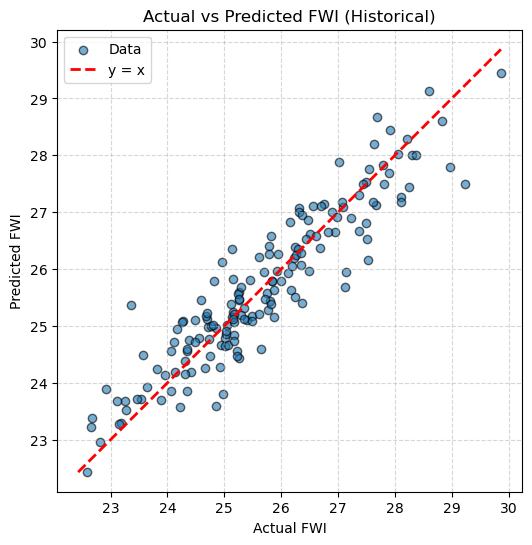

In [94]:
x = hist_df["FWI"]
y = hist_df["FWI_pred"]

plt.figure(figsize=(6,6))
plt.scatter(x, y, alpha=0.6, edgecolor='k', label='Data')

# === 1:1 line (y = x) ===
lims = [
    np.min([x.min(), y.min()]),
    np.max([x.max(), y.max()]),
]
plt.plot(lims, lims, 'r--', lw=2, label='y = x')  # red dashed line

# === Labels, limits, and formatting ===
plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")
plt.title("Actual vs Predicted FWI (Historical)")
plt.legend()
plt.xlim(lims)
plt.ylim(lims)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis("equal")  # ensures equal aspect ratio

plt.show()

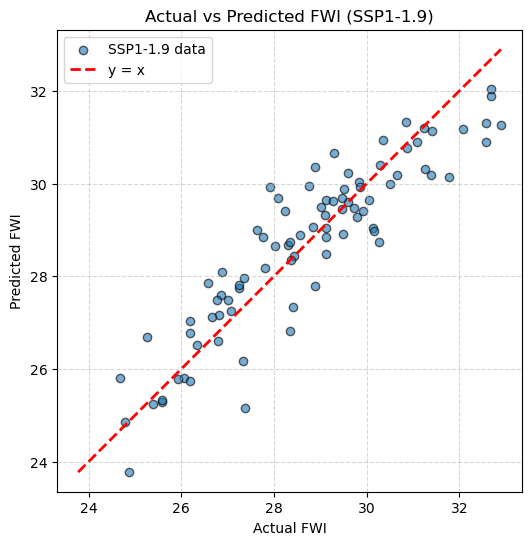

In [95]:
x = ssp119_df["FWI"]
y = ssp119_df["FWI_pred"]

plt.figure(figsize=(6,6))
plt.scatter(x, y, alpha=0.6, edgecolor='k', label='SSP1-1.9 data')

# === 1:1 line (y = x) ===
lims = [
    np.min([x.min(), y.min()]),
    np.max([x.max(), y.max()]),
]
plt.plot(lims, lims, 'r--', lw=2, label='y = x')

# === Labels, limits, and formatting ===
plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")
plt.title("Actual vs Predicted FWI (SSP1-1.9)")
plt.legend()
plt.xlim(lims)
plt.ylim(lims)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis("equal")

plt.show()

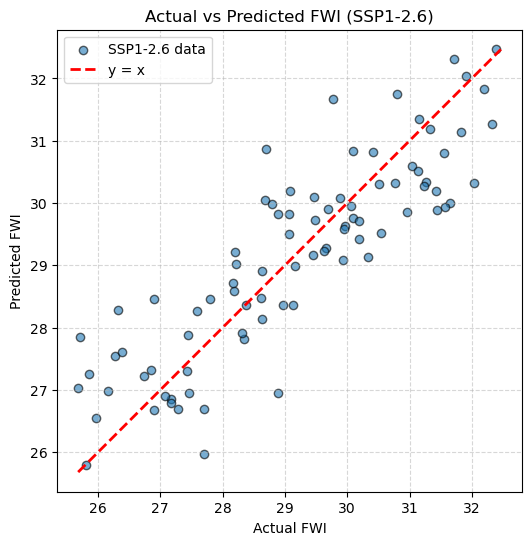

In [96]:
x = ssp126_df["FWI"]
y = ssp126_df["FWI_pred"]

plt.figure(figsize=(6,6))
plt.scatter(x, y, alpha=0.6, edgecolor='k', label='SSP1-2.6 data')

# === 1:1 line (y = x) ===
lims = [
    np.min([x.min(), y.min()]),
    np.max([x.max(), y.max()]),
]
plt.plot(lims, lims, 'r--', lw=2, label='y = x')

# === Labels, limits, and formatting ===
plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")
plt.title("Actual vs Predicted FWI (SSP1-2.6)")
plt.legend()
plt.xlim(lims)
plt.ylim(lims)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis("equal")

plt.show()

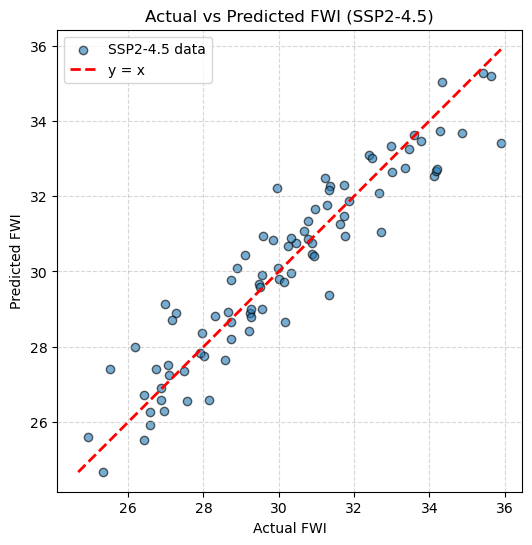

In [97]:
x = ssp245_df["FWI"]
y = ssp245_df["FWI_pred"]

plt.figure(figsize=(6,6))
plt.scatter(x, y, alpha=0.6, edgecolor='k', label='SSP2-4.5 data')

# === 1:1 line (y = x) ===
lims = [
    np.min([x.min(), y.min()]),
    np.max([x.max(), y.max()]),
]
plt.plot(lims, lims, 'r--', lw=2, label='y = x')

# === Labels, limits, and formatting ===
plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")
plt.title("Actual vs Predicted FWI (SSP2-4.5)")
plt.legend()
plt.xlim(lims)
plt.ylim(lims)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis("equal")

plt.show()

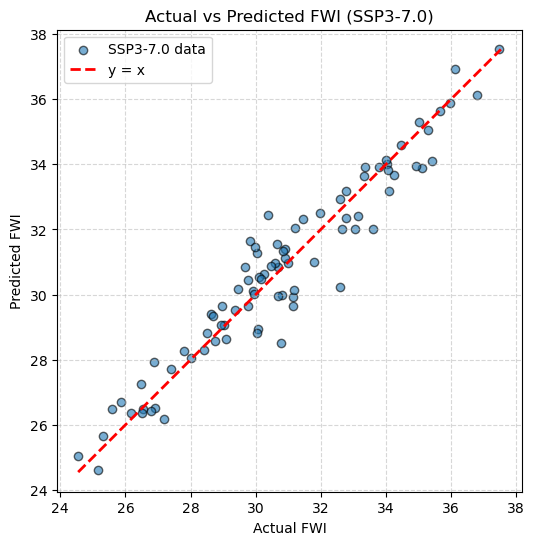

In [98]:
x = ssp370_df["FWI"]
y = ssp370_df["FWI_pred"]

plt.figure(figsize=(6,6))
plt.scatter(x, y, alpha=0.6, edgecolor='k', label='SSP3-7.0 data')

# === 1:1 line (y = x) ===
lims = [
    np.min([x.min(), y.min()]),
    np.max([x.max(), y.max()]),
]
plt.plot(lims, lims, 'r--', lw=2, label='y = x')

# === Labels, limits, and formatting ===
plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")
plt.title("Actual vs Predicted FWI (SSP3-7.0)")
plt.legend()
plt.xlim(lims)
plt.ylim(lims)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis("equal")

plt.show()

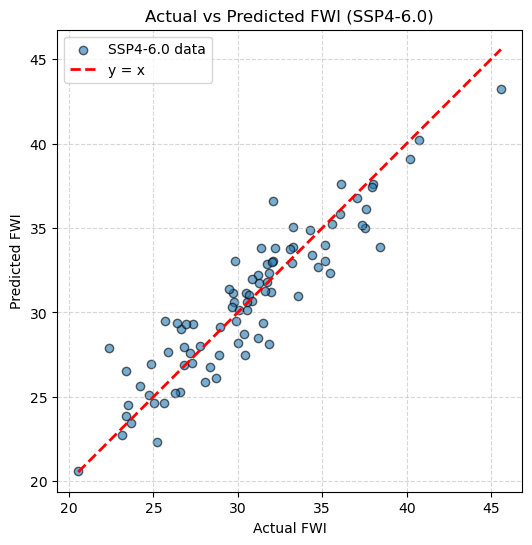

In [99]:
x = ssp460_df["FWI"]
y = ssp460_df["FWI_pred"]

plt.figure(figsize=(6,6))
plt.scatter(x, y, alpha=0.6, edgecolor='k', label='SSP4-6.0 data')

# === 1:1 line (y = x) ===
lims = [
    np.min([x.min(), y.min()]),
    np.max([x.max(), y.max()]),
]
plt.plot(lims, lims, 'r--', lw=2, label='y = x')

# === Labels, limits, and formatting ===
plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")
plt.title("Actual vs Predicted FWI (SSP4-6.0)")
plt.legend()
plt.xlim(lims)
plt.ylim(lims)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis("equal")

plt.show()

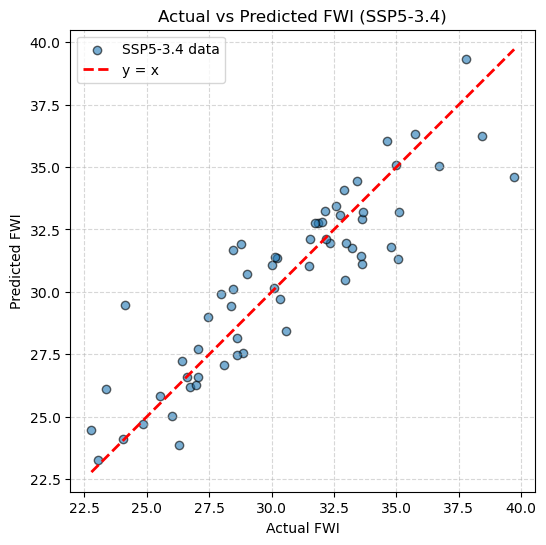

In [100]:
x = ssp534_df["FWI"]
y = ssp534_df["FWI_pred"]

plt.figure(figsize=(6,6))
plt.scatter(x, y, alpha=0.6, edgecolor='k', label='SSP5-3.4 data')

# === 1:1 line (y = x) ===
lims = [
    np.min([x.min(), y.min()]),
    np.max([x.max(), y.max()]),
]
plt.plot(lims, lims, 'r--', lw=2, label='y = x')

# === Labels, limits, and formatting ===
plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")
plt.title("Actual vs Predicted FWI (SSP5-3.4)")
plt.legend()
plt.xlim(lims)
plt.ylim(lims)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis("equal")

plt.show()

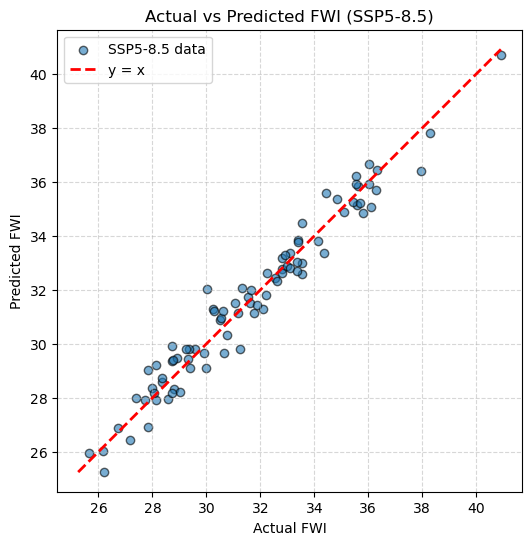

In [101]:
x = ssp585_df["FWI"]
y = ssp585_df["FWI_pred"]

plt.figure(figsize=(6,6))
plt.scatter(x, y, alpha=0.6, edgecolor='k', label='SSP5-8.5 data')

# === 1:1 line (y = x) ===
lims = [
    np.min([x.min(), y.min()]),
    np.max([x.max(), y.max()]),
]
plt.plot(lims, lims, 'r--', lw=2, label='y = x')

# === Labels, limits, and formatting ===
plt.xlabel("Actual FWI")
plt.ylabel("Predicted FWI")
plt.title("Actual vs Predicted FWI (SSP5-8.5)")
plt.legend()
plt.xlim(lims)
plt.ylim(lims)
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis("equal")

plt.show()

In [102]:
import statsmodels.formula.api as smf
from scipy.stats import zscore
# --- 1) Check that panel_df_th exists and is non-empty ---
assert 'panel_df_th' in globals(), "panel_df_th not found. Run the preprocess step first."
assert len(panel_df_th) > 0, "Empty panel_df_th after preprocessing."

# (Reminder: tasmax = °C, pr = mm/day, hurs = %, sfcWind = m/s, FWI = dimensionless)

# --- 2) Build formula with fixed effects for scenario if >= 2 unique scenarios ---
use_fe = panel_df_th['scenario'].nunique() >= 2
formula = "FWI ~ tasmax + pr + hursmin + sfcWind" + (" + C(scenario)" if use_fe else "")

# --- 3) Fit OLS with robust standard errors (HC1) ---
mlr_model = smf.ols(formula, data=panel_df_th).fit(cov_type='HC1')
print("\n=== OLS (HC1 robust SE) ===")
print(mlr_model.summary())

# --- 4) Standardized (beta) coefficients for effect size comparison ---
df_std = panel_df_th.copy()
to_z = ['FWI','tasmax','pr','hursmin','sfcWind']  # do not standardize categorical vars
df_std[to_z] = df_std[to_z].apply(zscore)

mlr_model_beta = smf.ols(formula, data=df_std).fit(cov_type='HC1')
print("\n=== Standardized (beta) coefficients ===")
print(mlr_model_beta.params[['tasmax','pr','hursmin','sfcWind']])
print("\n(Positive beta ⇒ variable increases as FWI increases, Negative beta ⇒ inverse relationship)")

# --- 5) Optional: table of coefficients, SE, CI, p-values ---
coef_table = pd.DataFrame({
    'coef'   : mlr_model.params,
    'HC1_se' : mlr_model.bse,
    't'      : mlr_model.tvalues,
    'pvalue' : mlr_model.pvalues,
})
coef_table['CI_low']  = coef_table['coef'] - 1.96*coef_table['HC1_se']
coef_table['CI_high'] = coef_table['coef'] + 1.96*coef_table['HC1_se']
print("\n=== Coefficients table (HC1) ===")
print(coef_table.round(4))


=== OLS (HC1 robust SE) ===
                            OLS Regression Results                            
Dep. Variable:                    FWI   R-squared:                       0.898
Model:                            OLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                     852.0
Date:                Tue, 02 Dec 2025   Prob (F-statistic):               0.00
Time:                        15:55:28   Log-Likelihood:                -1135.8
No. Observations:                 742   AIC:                             2296.
Df Residuals:                     730   BIC:                             2351.
Df Model:                          11                                         
Covariance Type:                  HC1                                         
                                                                                                coef    std err          z      P>|z|      [0.025      0.975]
-----------------------

In [104]:
# Optional: map to short names
scenario_map = {
    "Historical to Present (1850-2015)": "Historical",
    'SSP1-1.9 ("Sustainability - Very Low Emissions")': "SSP119",
    'SSP1-2.6 ("Sustainability - Low Emissions with Strong Mitigation")': "SSP126",
    'SSP2-4.5 ("Middle of the Road - Moderate Emissions")': "SSP245",
    'SSP3-7.0 ("Regional Rivalry - High Emissions")': "SSP370",
    'SSP4-3.4 ("Inequality - Intermediate Emissions")': "SSP434",
    'SSP4-6.0 ("Inequality - High Emissions")': "SSP460",
    'SSP5-3.4 ("Fossil-Fueled Development - Moderate Emissions")': "SSP534",
    'SSP5-8.5 ("Fossil-Fueled Development - High Emissions, No Climate Policy")': "SSP585",
}

panel_df_th["scenario_short"] = panel_df_th["scenario"].map(scenario_map)


In [105]:
import statsmodels.formula.api as smf
from scipy.stats import zscore
# --- 1) Check that panel_df_th exists and is non-empty ---
assert 'panel_df_th' in globals(), "panel_df_th not found. Run the preprocess step first."
assert len(panel_df_th) > 0, "Empty panel_df_th after preprocessing."

# (Reminder: tasmax = °C, pr = mm/day, hurs = %, sfcWind = m/s, FWI = dimensionless)

# --- 2) Build formula with fixed effects for scenario if >= 2 unique scenarios ---
use_fe = panel_df_th['scenario'].nunique() >= 2
formula = "FWI ~ tasmax + pr + hursmin + sfcWind" + (" + C(scenario)" if use_fe else "")

# --- 3) Fit OLS with robust standard errors (HC1) ---
mlr_model = smf.ols(formula, data=panel_df_th).fit(cov_type='HC1')
print("\n=== OLS (HC1 robust SE) ===")
print(mlr_model.summary())

# --- 4) Standardized (beta) coefficients for effect size comparison ---
df_std = panel_df_th.copy()
to_z = ['FWI','tasmax','pr','hursmin','sfcWind']  # do not standardize categorical vars
df_std[to_z] = df_std[to_z].apply(zscore)

mlr_model_beta = smf.ols(formula, data=df_std).fit(cov_type='HC1')
print("\n=== Standardized (beta) coefficients ===")
print(mlr_model_beta.params[['tasmax','pr','hursmin','sfcWind']])
print("\n(Positive beta ⇒ variable increases as FWI increases, Negative beta ⇒ inverse relationship)")

# --- 5) Optional: table of coefficients, SE, CI, p-values ---
coef_table = pd.DataFrame({
    'coef'   : mlr_model.params,
    'HC1_se' : mlr_model.bse,
    't'      : mlr_model.tvalues,
    'pvalue' : mlr_model.pvalues,
})
coef_table['CI_low']  = coef_table['coef'] - 1.96*coef_table['HC1_se']
coef_table['CI_high'] = coef_table['coef'] + 1.96*coef_table['HC1_se']
print("\n=== Coefficients table (HC1) ===")
print(coef_table.round(4))


=== OLS (HC1 robust SE) ===
                            OLS Regression Results                            
Dep. Variable:                    FWI   R-squared:                       0.898
Model:                            OLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                     852.0
Date:                Tue, 02 Dec 2025   Prob (F-statistic):               0.00
Time:                        15:55:28   Log-Likelihood:                -1135.8
No. Observations:                 742   AIC:                             2296.
Df Residuals:                     730   BIC:                             2351.
Df Model:                          11                                         
Covariance Type:                  HC1                                         
                                                                                                coef    std err          z      P>|z|      [0.025      0.975]
-----------------------

In [106]:
# =========================
# OLS per-scenario (HC1) + standardized betas + tidy tables
# =========================
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import zscore

# ---- 0) Settings ----
RESPONSE   = "FWI"
PREDICTORS = ["tasmax", "pr", "hursmin", "sfcWind"]   # swap "hurs" -> "h2o" if you prefer

# If you want shorter scenario names, you can map them first (optional):
scenario_map = {
    "Historical to Present (1850-2015)": "Historical",
    'SSP1-1.9 ("Sustainability - Very Low Emissions")': "SSP1-1.9",
    'SSP1-2.6 ("Sustainability - Low Emissions with Strong Mitigation")': "SSP1-2.6",
    'SSP2-4.5 ("Middle of the Road - Moderate Emissions")': "SSP2-4.5",
    'SSP3-7.0 ("Regional Rivalry - High Emissions")': "SSP3-7.0",
    'SSP4-3.4 ("Inequality - Intermediate Emissions")': "SSP4-3.4",
    'SSP4-6.0 ("Inequality - High Emissions")': "SSP4-6.0",
    'SSP5-3.4 ("Fossil-Fueled Development - Moderate Emissions")': "SSP5-3.4",
    'SSP5-8.5 ("Fossil-Fueled Development - High Emissions, No Climate Policy")': "SSP5-8.5",
}
panel_df_th["scenario_short"] = panel_df_th["scenario"].map(scenario_map).fillna(panel_df_th["scenario"])

scenarios = list(panel_df_th["scenario_short"].unique())

# Containers for combined outputs
per_sc_models       = {}         # scenario -> fitted model (unstandardized)
per_sc_models_beta  = {}         # scenario -> fitted model on z-scored data
coef_tables         = []         # long-form rows (per scenario)
beta_tables         = []         # standardized betas (per scenario)
metrics_rows        = []         # R2 etc.

for sc in scenarios:
    df_sc = panel_df_th.loc[panel_df_th["scenario_short"] == sc, [RESPONSE] + PREDICTORS].dropna()
    if df_sc.shape[0] < len(PREDICTORS) + 2:
        # too few rows to reliably fit; skip
        print(f"Skip {sc}: not enough rows ({df_sc.shape[0]})")
        continue

    # --- 1) Unstandardized OLS with HC1 ---
    formula_sc = f"{RESPONSE} ~ " + " + ".join(PREDICTORS)  # no FE term; this is per-scenario
    model_sc = smf.ols(formula_sc, data=df_sc).fit(cov_type="HC1")
    per_sc_models[sc] = model_sc

    # --- 2) Standardized betas (z-score within scenario) ---
    df_sc_std = df_sc.copy()
    cols_to_z = [RESPONSE] + PREDICTORS
    df_sc_std[cols_to_z] = df_sc_std[cols_to_z].apply(zscore)
    model_sc_beta = smf.ols(formula_sc, data=df_sc_std).fit(cov_type="HC1")
    per_sc_models_beta[sc] = model_sc_beta

    # --- 3) Collect tidy coef table (unstandardized) ---
    ct = pd.DataFrame({
        "scenario": sc,
        "term": model_sc.params.index,
        "coef": model_sc.params.values,
        "HC1_se": model_sc.bse.values,
        "t": model_sc.tvalues.values,
        "pvalue": model_sc.pvalues.values,
    })
    ct["CI_low"]  = ct["coef"] - 1.96 * ct["HC1_se"]
    ct["CI_high"] = ct["coef"] + 1.96 * ct["HC1_se"]
    coef_tables.append(ct)

    # --- 4) Collect standardized betas (only predictors) ---
    bt = pd.Series(
        {k: v for k, v in model_sc_beta.params.items() if k in PREDICTORS},
        name=sc
    )
    beta_tables.append(bt)

    # --- 5) Metrics per scenario ---
    metrics_rows.append(pd.Series({
        "scenario": sc,
        "n": df_sc.shape[0],
        "k": len(PREDICTORS),
        "R2": model_sc.rsquared,
        "Adj_R2": model_sc.rsquared_adj,
        "F": model_sc.fvalue if np.isfinite(model_sc.fvalue) else np.nan
    }))

# ---- Combine outputs ----
coef_table_all = pd.concat(coef_tables, ignore_index=True) if coef_tables else pd.DataFrame()
beta_table     = pd.DataFrame(beta_tables) if beta_tables else pd.DataFrame()
metrics_table  = pd.DataFrame(metrics_rows).set_index("scenario").sort_index() if metrics_rows else pd.DataFrame()

# ---- Pretty prints ----
print("\n=== OLS per-scenario: coefficients (HC1) ===")
if not coef_table_all.empty:
    print(coef_table_all.round(4))
else:
    print("No results (check data filtering).")

print("\n=== Standardized (beta) coefficients by scenario ===")
if not beta_table.empty:
    print(beta_table.round(3))
else:
    print("No beta results (check data filtering).")

print("\n=== Model metrics per scenario ===")
if not metrics_table.empty:
    print(metrics_table.round(3))
else:
    print("No metrics results (check data filtering).")



=== OLS per-scenario: coefficients (HC1) ===
      scenario       term         coef      HC1_se        t  pvalue  \
0   Historical  Intercept      83.2245     16.6362   5.0026  0.0000   
1   Historical     tasmax       2.1779      0.3358   6.4858  0.0000   
2   Historical         pr   69699.3354  28263.3953   2.4661  0.0137   
3   Historical    hursmin      -2.0560      0.1460 -14.0853  0.0000   
4   Historical    sfcWind       4.3644      1.7704   2.4652  0.0137   
5     SSP1-1.9  Intercept     183.8327     30.0300   6.1216  0.0000   
6     SSP1-1.9     tasmax       0.1158      0.5843   0.1982  0.8429   
7     SSP1-1.9         pr  114317.5623  63979.6656   1.7868  0.0740   
8     SSP1-1.9    hursmin      -2.4416      0.2446  -9.9815  0.0000   
9     SSP1-1.9    sfcWind      -1.5626      1.9194  -0.8141  0.4156   
10    SSP1-2.6  Intercept     250.2401     32.7586   7.6389  0.0000   
11    SSP1-2.6     tasmax      -1.1378      0.5069  -2.2444  0.0248   
12    SSP1-2.6         pr  2597

In [107]:
# === Add this import at the top ===
from statsmodels.stats.outliers_influence import variance_inflation_factor

# === Helper: compute VIF for a predictor matrix ===
def compute_vif(df_pred: pd.DataFrame) -> pd.DataFrame:
    X = df_pred.copy()

    # Drop zero-variance columns (VIF is undefined)
    keep = X.columns[X.nunique(dropna=True) > 1]
    X = X[keep]

    if X.shape[1] == 0:
        return pd.DataFrame(columns=["Variable", "VIF", "Tolerance"])

    # Add intercept; exclude it from the final output
    X = X.assign(const=1.0)

    vals = X.values
    cols = list(X.columns)
    rows = []
    for i, col in enumerate(cols):
        try:
            v = variance_inflation_factor(vals, i)
        except Exception:
            v = np.nan
        rows.append((col, v))

    out = pd.DataFrame(rows, columns=["Variable", "VIF"])
    out = out[out["Variable"] != "const"].reset_index(drop=True)
    out["Tolerance"] = 1.0 / out["VIF"]
    return out

# === Collect VIFs per scenario ===
vif_tables = []  # long form

for sc in scenarios:
    df_sc = panel_df_th.loc[panel_df_th["scenario_short"] == sc, [RESPONSE] + PREDICTORS].dropna()
    if df_sc.shape[0] < len(PREDICTORS) + 2:
        print(f"Skip {sc}: not enough rows ({df_sc.shape[0]})")
        continue

    # --- your existing code (models, betas, tables) stays the same ---
    formula_sc = f"{RESPONSE} ~ " + " + ".join(PREDICTORS)
    model_sc = smf.ols(formula_sc, data=df_sc).fit(cov_type="HC1")
    per_sc_models[sc] = model_sc

    df_sc_std = df_sc.copy()
    cols_to_z = [RESPONSE] + PREDICTORS
    df_sc_std[cols_to_z] = df_sc_std[cols_to_z].apply(zscore)
    model_sc_beta = smf.ols(formula_sc, data=df_sc_std).fit(cov_type="HC1")
    per_sc_models_beta[sc] = model_sc_beta

    ct = pd.DataFrame({
        "scenario": sc,
        "term": model_sc.params.index,
        "coef": model_sc.params.values,
        "HC1_se": model_sc.bse.values,
        "t": model_sc.tvalues.values,
        "pvalue": model_sc.pvalues.values,
    })
    ct["CI_low"]  = ct["coef"] - 1.96 * ct["HC1_se"]
    ct["CI_high"] = ct["coef"] + 1.96 * ct["HC1_se"]
    coef_tables.append(ct)

    bt = pd.Series({k: v for k, v in model_sc_beta.params.items() if k in PREDICTORS}, name=sc)
    beta_tables.append(bt)

    metrics_rows.append(pd.Series({
        "scenario": sc,
        "n": df_sc.shape[0],
        "k": len(PREDICTORS),
        "R2": model_sc.rsquared,
        "Adj_R2": model_sc.rsquared_adj,
        "F": model_sc.fvalue if np.isfinite(model_sc.fvalue) else np.nan
    }))

    # --- NEW: VIF per scenario ---
    vif_sc = compute_vif(df_sc[PREDICTORS])
    vif_sc.insert(0, "scenario", sc)
    vif_sc["n"] = df_sc.shape[0]
    vif_tables.append(vif_sc)

# === Combine existing outputs ===
coef_table_all = pd.concat(coef_tables, ignore_index=True) if coef_tables else pd.DataFrame()
beta_table     = pd.DataFrame(beta_tables) if beta_tables else pd.DataFrame()
metrics_table  = pd.DataFrame(metrics_rows).set_index("scenario").sort_index() if metrics_rows else pd.DataFrame()

# === Combine VIF per scenario (long + wide) ===
vif_per_scenario_long = pd.concat(vif_tables, ignore_index=True) if vif_tables else pd.DataFrame()
vif_per_scenario_wide = (
    vif_per_scenario_long.pivot(index="scenario", columns="Variable", values="VIF")
    if not vif_per_scenario_long.empty else pd.DataFrame()
)

print("\n=== VIF per scenario (long) ===")
print(vif_per_scenario_long.round(3) if not vif_per_scenario_long.empty else "No VIF results.")

print("\n=== VIF per scenario (wide) ===")
print(vif_per_scenario_wide.round(3) if not vif_per_scenario_wide.empty else "No VIF results.")

# === NEW: VIF on ALL SSPs pooled ===
df_all = panel_df_th[[RESPONSE] + PREDICTORS].dropna()
vif_all_ssp = compute_vif(df_all[PREDICTORS])

print("\n=== VIF (all SSPs pooled) ===")
print(vif_all_ssp.round(3) if not vif_all_ssp.empty else "No VIF results.")

# === Optional: flag scenarios with any VIF>5 in your metrics table ===
if not metrics_table.empty and not vif_per_scenario_wide.empty:
    metrics_table = metrics_table.join((vif_per_scenario_wide > 5).any(axis=1).rename("Any_VIF_gt5"), how="left")
    print("\n=== Model metrics (+ Any_VIF_gt5) ===")
    print(metrics_table.round(3))



=== VIF per scenario (long) ===
      scenario Variable    VIF  Tolerance    n
0   Historical   tasmax  1.837      0.544  165
1   Historical       pr  3.387      0.295  165
2   Historical  hursmin  3.778      0.265  165
3   Historical  sfcWind  1.096      0.912  165
4     SSP1-1.9   tasmax  4.717      0.212   86
5     SSP1-1.9       pr  2.572      0.389   86
6     SSP1-1.9  hursmin  6.130      0.163   86
7     SSP1-1.9  sfcWind  1.180      0.848   86
8     SSP1-2.6   tasmax  3.846      0.260   86
9     SSP1-2.6       pr  2.338      0.428   86
10    SSP1-2.6  hursmin  4.089      0.245   86
11    SSP1-2.6  sfcWind  1.187      0.842   86
12    SSP2-4.5   tasmax  4.322      0.231   86
13    SSP2-4.5       pr  2.194      0.456   86
14    SSP2-4.5  hursmin  4.692      0.213   86
15    SSP2-4.5  sfcWind  1.506      0.664   86
16    SSP3-7.0   tasmax  3.870      0.258   86
17    SSP3-7.0       pr  2.268      0.441   86
18    SSP3-7.0  hursmin  5.556      0.180   86
19    SSP3-7.0  sfcWind  2.

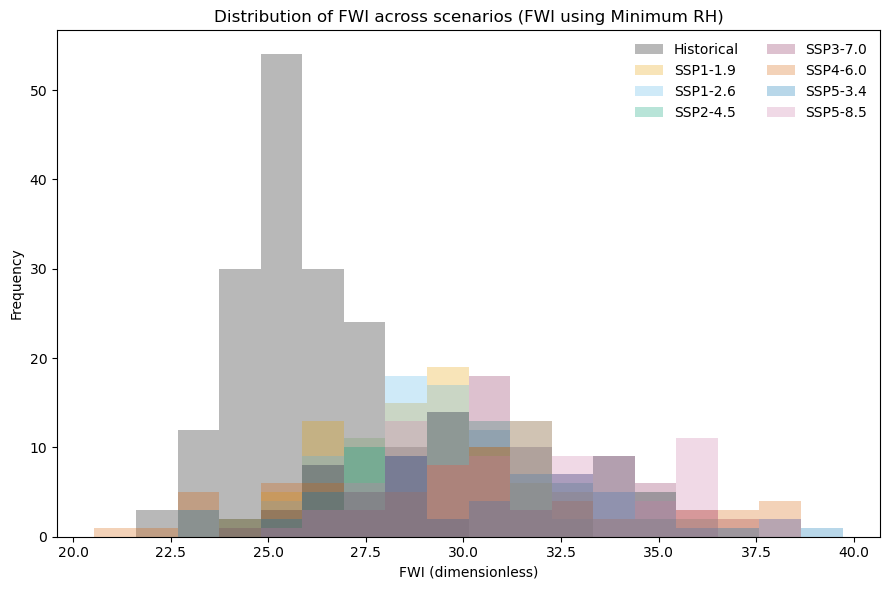

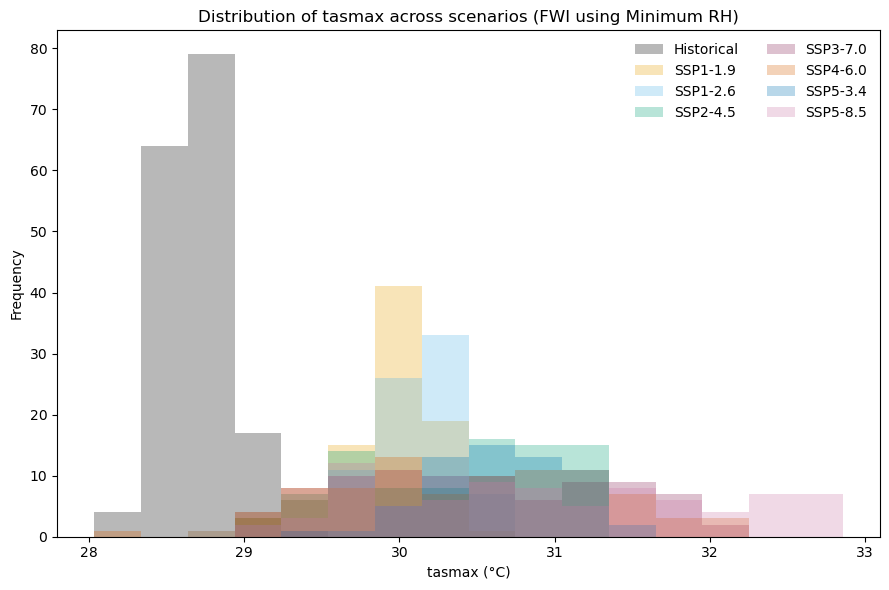

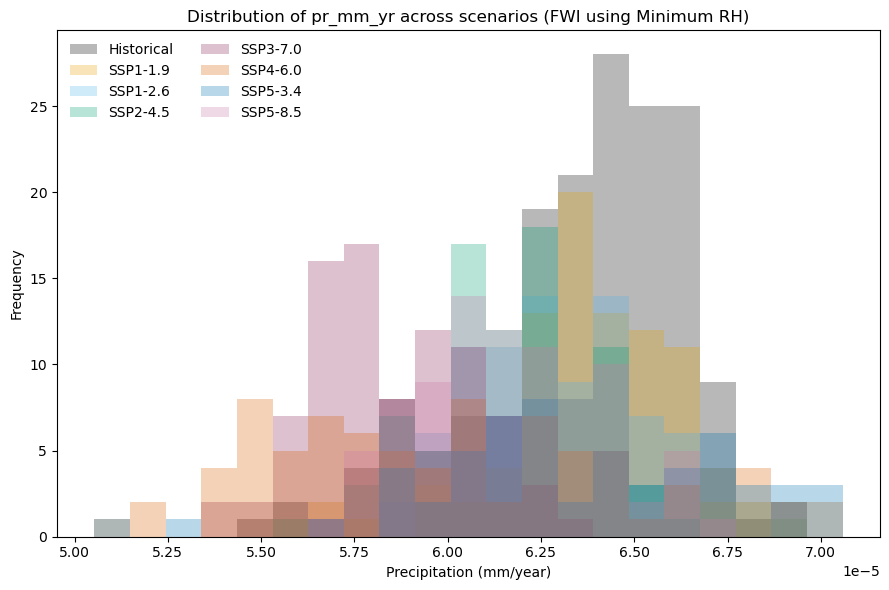

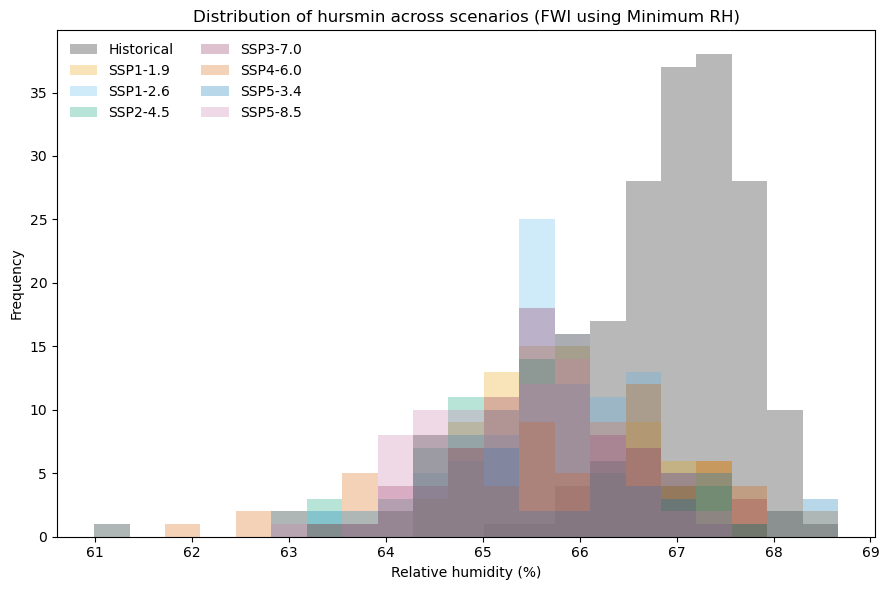

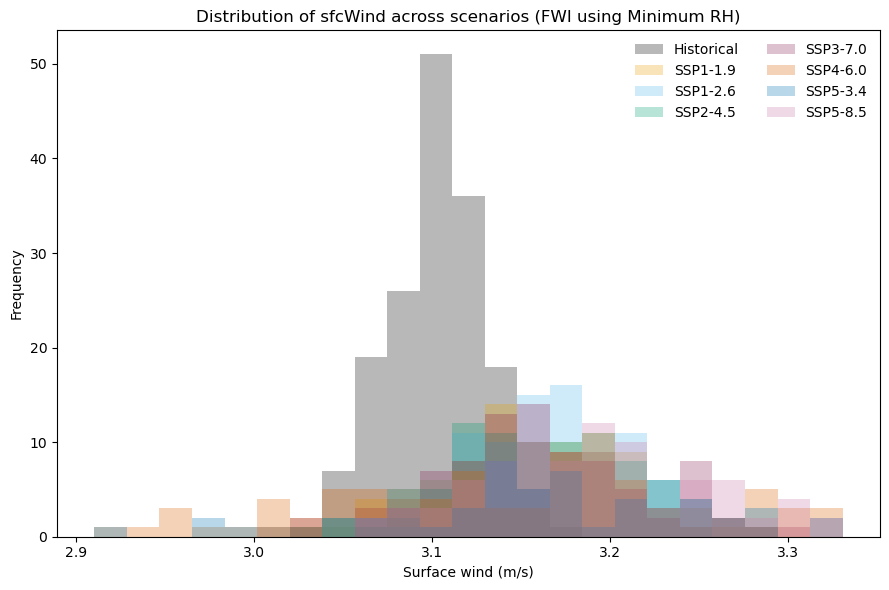

In [108]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===================== CONFIG =====================
df = panel_df_th.copy()   # or panel_df_th, etc.

# If you know the exact pr unit coming in, set this:
#   "auto" | "kg m-2 s-1" | "mm/day" | "mm/yr"
PR_UNIT_IN = "mm/yr"

DAYS_PER_YEAR = 365.2422
SECONDS_PER_DAY = 86400.0
SECONDS_PER_YEAR = SECONDS_PER_DAY * DAYS_PER_YEAR

# Variables to plot (we'll replace 'pr' with 'pr_mm_yr' after conversion)
vars_to_plot = ["FWI", "tasmax", "pr_mm_yr", "hursmin", "sfcWind"]

palette_all = {
    "Historical": "#000000",
    "SSP1-1.9":   "#E69F00",
    "SSP1-2.6":   "#56B4E9",
    "SSP2-4.5":   "#009E73",
    "SSP3-7.0":   "#882255",
    "SSP4-3.4":   "#E6D600",
    "SSP4-6.0":   "#D55E00",
    "SSP5-3.4":   "#0072B2",
    "SSP5-8.5":   "#CC79A7",
}

labels_map = {
    "FWI": "FWI (dimensionless)",
    "tasmax": "tasmax (°C)",
    "pr_mm_yr": "Precipitation (mm/year)",
    "hursmin": "Relative humidity (%)",
    "sfcWind": "Surface wind (m/s)",
}

upper_pct = 99.5          # None to disable tail trim
logx_vars = set()         # e.g., {"pr_mm_yr"} if you want log scale

# ===================== HELPERS =====================
def canonical_scenario(s):
    if pd.isna(s): return s
    s = str(s)
    if "Historical" in s or "1850-2015" in s:
        return "Historical"
    m = re.search(r"SSP[1-5]-\d(?:\.\d)?", s)
    return m.group(0) if m else s.strip()

def pr_to_mm_per_year(series, assume="auto"):
    x = pd.to_numeric(series, errors="coerce").astype(float)
    if assume == "kg m-2 s-1":
        return x * SECONDS_PER_YEAR
    elif assume == "mm/day":
        return x * DAYS_PER_YEAR
    elif assume == "mm/yr":
        return x
    else:
        # Heuristic: if the upper tail is < 1, it's almost certainly kg m-2 s-1.
        # (Typical mm/day annual means are several mm/day in Thailand)
        q95 = np.nanpercentile(x, 95)
        if np.isfinite(q95) and q95 < 1.0:
            return x * SECONDS_PER_YEAR
        else:
            return x * DAYS_PER_YEAR

def common_bins(values, max_bins=120):
    edges = np.histogram_bin_edges(values, bins="fd")
    if len(edges) > max_bins:
        edges = np.linspace(edges.min(), edges.max(), max_bins)
    return edges

# ===================== PREP =====================
scenario_col = "scenario_short" if "scenario_short" in df.columns else "scenario"
df["scenario"] = df[scenario_col].apply(canonical_scenario)

canonical_order = ["Historical","SSP1-1.9","SSP1-2.6","SSP2-4.5","SSP3-7.0","SSP4-3.4","SSP4-6.0","SSP5-3.4","SSP5-8.5"]
present = [s for s in canonical_order if s in set(df["scenario"].dropna().unique())]
df = df[df["scenario"].isin(present)].copy()
df["scenario"] = pd.Categorical(df["scenario"], categories=present, ordered=True)

# Units: tasmax K -> °C if needed (guard in case your builder didn't convert)
if pd.to_numeric(df["tasmax"], errors="coerce").median() > 100:
    df["tasmax"] = pd.to_numeric(df["tasmax"], errors="coerce") - 273.15

# Convert precipitation to mm/year
df["pr_mm_yr"] = pr_to_mm_per_year(df["pr"], assume=PR_UNIT_IN)
# Remove tiny negatives (numerical noise)
df["pr_mm_yr"] = df["pr_mm_yr"].clip(lower=0)

# Ensure numeric + drop NaNs for plotted vars
for col in vars_to_plot:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=vars_to_plot + ["scenario"])

# Color map for only the scenarios present
palette = {k: palette_all[k] for k in present if k in palette_all}

# ===================== PLOT =====================
for var in vars_to_plot:
    pooled = df[var].to_numpy()
    if pooled.size == 0:
        continue
    if upper_pct is not None:
        cap = np.nanpercentile(pooled, upper_pct)
        pooled = pooled[pooled <= cap]
    bins = common_bins(pooled)

    plt.figure(figsize=(9,6))
    for scen in present:
        vals = df.loc[df["scenario"] == scen, var].to_numpy()
        if vals.size == 0:
            continue
        if upper_pct is not None:
            vals = vals[vals <= cap]
        plt.hist(vals, bins=bins, alpha=0.28, label=scen, color=palette.get(scen))
    plt.xlabel(labels_map.get(var, var))
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {var} across scenarios (FWI using Minimum RH)")
    if var in logx_vars and np.any(pooled > 0):
        plt.xscale("log")
    plt.legend(frameon=False, ncol=2)
    plt.tight_layout()
    plt.show()


In [109]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ===================== CONFIG =====================
df = panel_df_th.copy()   # or panel_df_th, etc.

# If you know the exact pr unit coming in, set this:
#   "auto" | "kg m-2 s-1" | "mm/day" | "mm/yr"
PR_UNIT_IN = "mm/yr"

DAYS_PER_YEAR = 365.2422
SECONDS_PER_DAY = 86400.0
SECONDS_PER_YEAR = SECONDS_PER_DAY * DAYS_PER_YEAR

# Variables to plot (we'll replace 'pr' with 'pr_mm_yr' after conversion)
vars_to_plot = ["FWI", "tasmax", "pr_mm_yr", "hursmin", "sfcWind"]

palette_all = {
    "Historical": "#000000",
    "SSP1-1.9":   "#E69F00",
    "SSP1-2.6":   "#56B4E9",
    "SSP2-4.5":   "#009E73",
    "SSP3-7.0":   "#882255",
    "SSP4-3.4":   "#E6D600",
    "SSP4-6.0":   "#D55E00",
    "SSP5-3.4":   "#0072B2",
    "SSP5-8.5":   "#CC79A7",
}

labels_map = {
    "FWI": "FWI (dimensionless)",
    "tasmax": "tasmax (°C)",
    "pr_mm_yr": "Precipitation (mm/year)",
    "hursmin": "Relative humidity (%)",
    "sfcWind": "Surface wind (m/s)",
}

upper_pct = 99.5          # None to disable tail trim
logx_vars = set()         # e.g., {"pr_mm_yr"} if you want log scale

# ---- Saving options ----
OUTPUT_DIR = Path("fig_distros")   # change as you like
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SAVE_FORMATS = ["png", "pdf"]      # add "svg" if you want
DPI = 200
TRANSPARENT = False

# ===================== HELPERS =====================
def canonical_scenario(s):
    if pd.isna(s): return s
    s = str(s)
    if "Historical" in s or "1850-2015" in s:
        return "Historical"
    m = re.search(r"SSP[1-5]-\d(?:\.\d)?", s)
    return m.group(0) if m else s.strip()

def pr_to_mm_per_year(series, assume="auto"):
    x = pd.to_numeric(series, errors="coerce").astype(float)
    if assume == "kg m-2 s-1":
        return x * SECONDS_PER_YEAR
    elif assume == "mm/day":
        return x * DAYS_PER_YEAR
    elif assume == "mm/yr":
        return x
    else:
        # Heuristic: if the upper tail is < 1, it's almost certainly kg m-2 s-1.
        q95 = np.nanpercentile(x, 95)
        if np.isfinite(q95) and q95 < 1.0:
            return x * SECONDS_PER_YEAR
        else:
            return x * DAYS_PER_YEAR

def common_bins(values, max_bins=120):
    edges = np.histogram_bin_edges(values, bins="fd")
    if len(edges) > max_bins:
        edges = np.linspace(edges.min(), edges.max(), max_bins)
    return edges

# ===================== PREP =====================
scenario_col = "scenario_short" if "scenario_short" in df.columns else "scenario"
df["scenario"] = df[scenario_col].apply(canonical_scenario)

canonical_order = ["Historical","SSP1-1.9","SSP1-2.6","SSP2-4.5","SSP3-7.0","SSP4-3.4","SSP4-6.0","SSP5-3.4","SSP5-8.5"]
present = [s for s in canonical_order if s in set(df["scenario"].dropna().unique())]
df = df[df["scenario"].isin(present)].copy()
df["scenario"] = pd.Categorical(df["scenario"], categories=present, ordered=True)

# Units: tasmax K -> °C if needed (guard in case your builder didn't convert)
if pd.to_numeric(df["tasmax"], errors="coerce").median() > 100:
    df["tasmax"] = pd.to_numeric(df["tasmax"], errors="coerce") - 273.15

# Convert precipitation to mm/year
df["pr_mm_yr"] = pr_to_mm_per_year(df["pr"], assume=PR_UNIT_IN)
# Remove tiny negatives (numerical noise)
df["pr_mm_yr"] = df["pr_mm_yr"].clip(lower=0)

# Ensure numeric + drop NaNs for plotted vars
for col in vars_to_plot:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=vars_to_plot + ["scenario"])

# Color map for only the scenarios present
palette = {k: palette_all[k] for k in present if k in palette_all}

# ===================== PLOT =====================
for var in vars_to_plot:
    pooled = df[var].to_numpy()
    if pooled.size == 0:
        continue
    if upper_pct is not None:
        cap = np.nanpercentile(pooled, upper_pct)
        pooled = pooled[pooled <= cap]
    bins = common_bins(pooled)

    fig, ax = plt.subplots(figsize=(9, 6))

    for scen in present:
        vals = df.loc[df["scenario"] == scen, var].to_numpy()
        if vals.size == 0:
            continue
        if upper_pct is not None:
            vals = vals[vals <= cap]
        # counts (frequency); density=False is default but we set it explicitly
        ax.hist(vals, bins=bins, alpha=0.28, label=scen, color=palette.get(scen), density=False)

    ax.set_xlabel(labels_map.get(var, var))
    ax.set_ylabel("Frequency")  # counts, not density
    ax.set_title(f"Distribution of {var} across scenarios (FWI using Minimum RH)")
    if var in logx_vars and np.any(pooled > 0):
        ax.set_xscale("log")
    ax.legend(frameon=False, ncol=2)
    fig.tight_layout()

    # ---- Save to all requested formats ----
    base = OUTPUT_DIR / f"dist_{var}"
    for ext in SAVE_FORMATS:
        fig.savefig(f"{base}.{ext}", dpi=DPI, transparent=TRANSPARENT, bbox_inches="tight")

    plt.close(fig)  # important when looping many figures


In [112]:
panel_df_th.copy()

,time,FWI,tasmax,pr,hursmin,sfcWind,scenario,scenario_short
0,1850,23.354528,28.563599,0.000064,67.203018,3.123170,Historical to Present (1850-2015),Historical
1,1851,25.219310,28.646515,0.000066,67.587181,3.051434,Historical to Present (1850-2015),Historical
2,1852,25.745036,28.575317,0.000064,67.135033,3.135036,Historical to Present (1850-2015),Historical
3,1853,26.503480,28.601959,0.000064,66.585442,3.106359,Historical to Present (1850-2015),Historical
4,1854,26.158625,28.711395,0.000063,66.516777,3.086019,Historical to Present (1850-2015),Historical
...,...,...,...,...,...,...,...,...
737,2096,32.228517,32.706787,0.000065,65.685829,3.260822,"SSP5-8.5 (""Fossil-Fueled Development - High Em...",SSP5-8.5
738,2097,35.790292,32.700165,0.000059,64.455223,3.309518,"SSP5-8.5 (""Fossil-Fueled Development - High Em...",SSP5-8.5
739,2098,38.273405,33.153198,0.000062,63.731720,3.258732,"SSP5-8.5 (""Fossil-Fueled Development - High Em...",SSP5-8.5
740,2099,35.531894,32.861938,0.000059,64.066185,3.272016,"SSP5-8.5 (""Fossil-Fueled Development - High Em...",SSP5-8.5


In [113]:
# ========= OVERLAID HISTOGRAMS: STEP + HATCH =========
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ===================== CONFIG =====================
df = panel_df_th.copy()   # <- your DataFrame

#   "auto" | "kg m-2 s-1" | "mm/day" | "mm/yr"
PR_UNIT_IN = "mm/yr"

DAYS_PER_YEAR = 365.2422
SECONDS_PER_DAY = 86400.0
SECONDS_PER_YEAR = SECONDS_PER_DAY * DAYS_PER_YEAR

vars_to_plot = ["FWI", "tasmax", "pr_mm_yr", "hursmin", "sfcWind"]

palette_all = {
    "Historical": "#000000",
    "SSP1-1.9":   "#E69F00",
    "SSP1-2.6":   "#56B4E9",
    "SSP2-4.5":   "#009E73",
    "SSP3-7.0":   "#882255",
    "SSP4-3.4":   "#E6D600",
    "SSP4-6.0":   "#D55E00",
    "SSP5-3.4":   "#0072B2",
    "SSP5-8.5":   "#CC79A7",
}

labels_map = {
    "FWI": "FWI (dimensionless)",
    "tasmax": "tasmax (°C)",
    "pr_mm_yr": "Precipitation (mm/year)",
    "hursmin": "Relative humidity (%)",
    "sfcWind": "Surface wind (m/s)",
}

upper_pct = 99.5
logx_vars = set()         # e.g., {"pr_mm_yr"}

# ---- Saving options ----
OUTPUT_DIR = Path("fig_distros_OVERLAID_newstyle_MRI_hursmin")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SAVE_FORMATS = ["png", "pdf"]
DPI = 200
TRANSPARENT = False

# ===================== STYLE MAPS =====================
hatch_map = {
    "Historical": "",
    "SSP1-1.9":  "//",
    "SSP1-2.6":  "\\\\",
    "SSP2-4.5":  "xx",
    "SSP3-7.0":  "..",
    # "SSP4-3.4":  "++",
    "SSP4-6.0":  "**",
    "SSP5-3.4":  "oo",
    "SSP5-8.5":  "--",
}

# IMPORTANT: use only string linestyles to avoid ValueError inside Axes.hist
line_map_str = {
    "Historical": "solid",
    "SSP1-1.9":  "dashed",
    "SSP1-2.6":  "dotted",
    "SSP2-4.5":  "dashdot",
    "SSP3-7.0":  "dashed",
    # "SSP4-3.4":  "dotted",
    "SSP4-6.0":  "dashdot",
    "SSP5-3.4":  "dashed",
    "SSP5-8.5":  "dotted",
}

def _safe_linestyle(scen):
    ls = line_map_str.get(scen, "solid")
    # Matplotlib’s hist will cycle/np.atleast_1d this—keep it a plain string.
    return ls

# ===================== HELPERS =====================
def canonical_scenario(s):
    if pd.isna(s): return s
    s = str(s)
    if "Historical" in s or "1850-2015" in s:
        return "Historical"
    m = re.search(r"SSP[1-5]-\d(?:\.\d)?", s)
    return m.group(0) if m else s.strip()

def pr_to_mm_per_year(series, assume="auto"):
    x = pd.to_numeric(series, errors="coerce").astype(float)
    if assume == "kg m-2 s-1":
        return x * SECONDS_PER_YEAR
    elif assume == "mm/day":
        return x * DAYS_PER_YEAR
    elif assume == "mm/yr":
        return x
    else:
        q95 = np.nanpercentile(x, 95)
        if np.isfinite(q95) and q95 < 1.0:
            return x * SECONDS_PER_YEAR
        else:
            return x * DAYS_PER_YEAR

def common_bins(values, max_bins=120):
    edges = np.histogram_bin_edges(values, bins="fd")
    if len(edges) > max_bins:
        edges = np.linspace(edges.min(), edges.max(), max_bins)
    return edges

# ===================== PREP =====================
scenario_col = "scenario_short" if "scenario_short" in df.columns else "scenario"
df["scenario"] = df[scenario_col].apply(canonical_scenario)

canonical_order = ["Historical","SSP1-1.9","SSP1-2.6","SSP2-4.5","SSP3-7.0","SSP4-6.0","SSP5-3.4","SSP5-8.5"]
present = [s for s in canonical_order if s in set(df["scenario"].dropna().unique())]
df = df[df["scenario"].isin(present)].copy()
df["scenario"] = pd.Categorical(df["scenario"], categories=present, ordered=True)

# Units: tasmax K -> °C if needed
if pd.to_numeric(df["tasmax"], errors="coerce").median() > 100:
    df["tasmax"] = pd.to_numeric(df["tasmax"], errors="coerce") - 273.15

# Convert precipitation to mm/year
df["pr_mm_yr"] = pr_to_mm_per_year(df["pr"], assume=PR_UNIT_IN).clip(lower=0)

# Ensure numeric + drop NaNs
for col in vars_to_plot:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=vars_to_plot + ["scenario"])

# Color map limited to present scenarios
palette = {k: palette_all[k] for k in present if k in palette_all}

# ===================== PLOT & SAVE =====================
from matplotlib.lines import Line2D

for var in vars_to_plot:
    pooled = df[var].to_numpy()
    if pooled.size == 0:
        continue
    if upper_pct is not None:
        cap = np.nanpercentile(pooled, upper_pct)
        pooled = pooled[pooled <= cap]
    bins = common_bins(pooled)

    fig, ax = plt.subplots(figsize=(9, 6))

    # Faint filled bars with hatches
    for scen in present:
        vals = df.loc[df["scenario"] == scen, var].to_numpy()
        if vals.size == 0:
            continue
        if upper_pct is not None:
            vals = vals[vals <= cap]
        n, edges, patches = ax.hist(
            vals, bins=bins, density=True, alpha=0.18,
            label=None, color=palette.get(scen), edgecolor="none"
        )
        for p in patches:
            p.set_hatch(hatch_map.get(scen, ""))

    # Step outlines on top (string linestyles only)
    for scen in present:
        vals = df.loc[df["scenario"] == scen, var].to_numpy()
        if vals.size == 0:
            continue
        if upper_pct is not None:
            vals = vals[vals <= cap]
        ax.hist(
            vals, bins=bins, density=True, histtype="step",
            linewidth=2.0, color=palette.get(scen),
            linestyle=_safe_linestyle(scen)
        )

    ax.set_xlabel(labels_map.get(var, var))
    ax.set_ylabel("Density")
    ax.set_title(f"Distribution of {var} across scenarios — Overlaid")
    if var in logx_vars and np.any(pooled > 0):
        ax.set_xscale("log")

    legend_elems = [Line2D([0],[0],
                           color=palette.get(s), linestyle=_safe_linestyle(s),
                           linewidth=2.0, label=s)
                    for s in present]
    ax.legend(handles=legend_elems, frameon=False, ncol=2)
    fig.tight_layout()

    base = OUTPUT_DIR / f"dist_{var}_overlaid"
    for ext in SAVE_FORMATS:
        fig.savefig(f"{base}.{ext}", dpi=DPI, transparent=TRANSPARENT, bbox_inches="tight")
    plt.close(fig)


C:\Users\asus\AppData\Local\Temp\ipykernel_15908\2255186567.py:206: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(bottom=0.18, top=0.88, wspace=0.25)


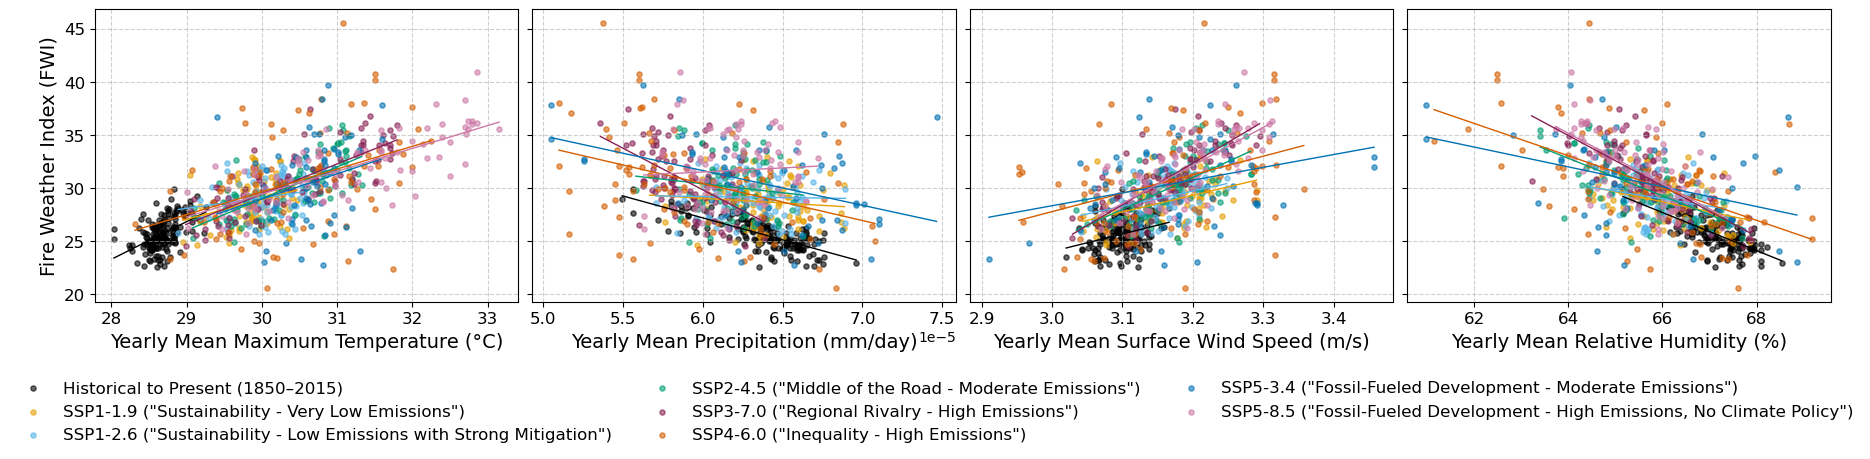

In [144]:
from scipy.stats import linregress
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

# --- Extended palette (colors keyed by short scenario keys) ---
color_blind_palette = {
    "Historical": "#000000",
    "SSP119": "#E69F00",
    "SSP126": "#56B4E9",
    "SSP245": "#009E73",
    "SSP370": "#882255",
    # "SSP434": "#E6D600",
    "SSP460": "#D55E00",
    "SSP534": "#0072B2",
    "SSP585": "#CC79A7",
}

# --- Full legend text per scenario key + desired legend order ---
SCENARIO_FULL = {
    "Historical": 'Historical to Present (1850–2015)',
    "SSP119":     'SSP1-1.9 ("Sustainability - Very Low Emissions")',
    "SSP126":     'SSP1-2.6 ("Sustainability - Low Emissions with Strong Mitigation")',
    "SSP245":     'SSP2-4.5 ("Middle of the Road - Moderate Emissions")',
    "SSP370":     'SSP3-7.0 ("Regional Rivalry - High Emissions")',
    # "SSP434":     'SSP4-3.4 ("Inequality - Intermediate Emissions")',
    "SSP460":     'SSP4-6.0 ("Inequality - High Emissions")',
    "SSP534":     'SSP5-3.4 ("Fossil-Fueled Development - Moderate Emissions")',
    "SSP585":     'SSP5-8.5 ("Fossil-Fueled Development - High Emissions, No Climate Policy")'
}
SCENARIO_SHORT = {
    "Historical": "Historical",
    "SSP119": "SSP1-1.9",
    "SSP126": "SSP1-2.6",
    "SSP245": "SSP2-4.5",
    "SSP370": "SSP3-7.0",
    "SSP460": "SSP4-6.0",
    "SSP534": "SSP5-3.4",
    "SSP585": "SSP5-8.5",
}

SCENARIO_ORDER = ["Historical","SSP119","SSP126","SSP245","SSP370","SSP460","SSP534","SSP585"]

def _scenario_key_from_label(label: str):
    """Map any incoming label text to a canonical scenario key for colors/legend lookup."""
    if not label:
        return None
    l = label.lower().replace(" ", "")
    lc = l.replace("-", "").replace(".", "")
    if "historical" in l: return "Historical"
    if "ssp1-1.9" in l or "ssp119" in lc: return "SSP119"
    if "ssp1-2.6" in l or "ssp126" in lc: return "SSP126"
    if "ssp2-4.5" in l or "ssp245" in lc: return "SSP245"
    if "ssp3-7.0" in l or "ssp370" in lc: return "SSP370"
    # if "ssp4-3.4" in l or "ssp434" in lc: return "SSP434"
    if "ssp4-6.0" in l or "ssp460" in lc: return "SSP460"
    if "ssp5-3.4" in l or "ssp534" in lc: return "SSP534"
    if "ssp5-8.5" in l or "ssp585" in lc: return "SSP585"
    return None

# ---------- helpers to accept Dataset OR DataArray, gridded OR series ----------
def _is_da(x): return isinstance(x, xr.DataArray)
def _is_ds(x): return isinstance(x, xr.Dataset)
def _has_latlon(da): return ("lat" in da.dims) and ("lon" in da.dims)

def _get_da(x, preferred=None):
    """Return a DataArray from Dataset/DataArray. If Dataset, try 'preferred' var else first var."""
    if _is_da(x):
        return x
    if _is_ds(x):
        if preferred and preferred in x:
            return x[preferred]
        # fallback: first data_var
        var = list(x.data_vars)[0]
        return x[var]
    raise TypeError("Expected xarray Dataset or DataArray")

def _area_field(a):
    """Return area weights DataArray or None."""
    if a is None: return None
    if _is_da(a): return a
    if _is_ds(a):
        if "area" in a: return a["area"]
        # fallback: first var
        return a[list(a.data_vars)[0]]
    return None

def _region_reduce(da, th_slice, area=None):
    """If lat/lon present: cut to Thailand and (weighted) mean over lat,lon. Else return as-is."""
    if _has_latlon(da):
        da_th = da.sel(**th_slice)
        if area is not None and _has_latlon(area):
            # align area to da_th grid if needed
            area_th = area.sel(lat=da_th.lat, lon=da_th.lon, method="nearest").sel(**th_slice)
            try:
                return da_th.weighted(area_th).mean(dim=["lat", "lon"])
            except Exception:
                return da_th.mean(dim=["lat", "lon"])
        else:
            return da_th.mean(dim=["lat", "lon"])
    return da  # already a time series

def _align_to_time(da, target_time):
    if "time" in da.dims:
        return da.sel(time=target_time, method="nearest")
    return da

def plot_fwi_vs_4vars_grid(
    datasets_fwi,
    datasets_tasmax,
    datasets_pr,
    datasets_sfcWind,
    datasets_hursmin,
    labels,
    area_default=None,                 # optional; used when inputs are gridded
    area_map=None,                     # optional dict per var
    title="FWI vs drivers (Thailand)",
    filename="FWI_vs_4drivers_Thailand_grid.png",
    th_slice=dict(lat=slice(5.5, 20.5), lon=slice(97.5, 105.5))
):
    # area handling
    area_map = area_map or {}
    area_def_da = _area_field(area_default)
    for k in ["tasmax", "pr", "sfcWind", "hursmin"]:
        area_map[k] = _area_field(area_map.get(k, area_def_da))

    fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(18, 3.5),
                             constrained_layout=True, sharey=True)

    panels = [
        dict(name="tasmax",  xlab="Yearly Mean Maximum Temperature (°C)", preferred="tasmax",  series=datasets_tasmax),
        dict(name="pr",      xlab="Yearly Mean Precipitation (mm/day)",   preferred="pr",      series=datasets_pr),
        dict(name="sfcWind", xlab="Yearly Mean Surface Wind Speed (m/s)", preferred="sfcWind", series=datasets_sfcWind),
        dict(name="hursmin",    xlab="Yearly Mean Relative Humidity (%)",    preferred="hursmin",    series=datasets_hursmin),
    ]

    # Collect one legend item per scenario key; store (handle, display_text)
    legend_items = {}

    for ax, panel in zip(axes, panels):
        preferred = panel["preferred"]
        for ds_fwi, ds_x, label_in in zip(datasets_fwi, panel["series"], labels):
            # --- Y (FWI) ---
            fwi_da = _get_da(ds_fwi, preferred="fwisa")
            fwi_ts = _region_reduce(fwi_da, th_slice, area=area_def_da)

            # --- X (variable) ---
            x_da = _get_da(ds_x, preferred=preferred)
            x_ts = _region_reduce(x_da, th_slice, area=area_map[panel["name"]])

            # Align times if both have time coords
            if "time" in fwi_ts.dims:
                x_ts = _align_to_time(x_ts, fwi_ts["time"])

            # ---- simple inline unit conversions/adjustments ----
            if panel["name"] == "pr":
                # If pr is in kg m-2 s-1 (CMIP6 default), convert to mm/day:
                # x_ts = x_ts * 86400.0
                panel["xlab"] = "Yearly Mean Precipitation (mm/day)"
            elif panel["name"] == "tasmax":
                # Kelvin → °C
                # x_ts = x_ts - 273.15
                panel["xlab"] = "Yearly Mean Maximum Temperature (°C)"

            x_vals = np.asarray(x_ts.values)
            y_vals = np.asarray(fwi_ts.values)

            # Clean NaNs and ensure same length
            m = (~np.isnan(x_vals)) & (~np.isnan(y_vals))
            x_vals, y_vals = x_vals[m], y_vals[m]
            if x_vals.size == 0 or y_vals.size == 0 or x_vals.size != y_vals.size:
                print(f"[Skip {panel['name']}] {label_in}: empty/mismatch — x={x_vals.size} y={y_vals.size}")
                continue

            # Map to canonical scenario key for color/legend, but show full legend text
            key = _scenario_key_from_label(label_in)
            color = color_blind_palette.get(key, "#000000")
            display_label = SCENARIO_SHORT.get(key, label_in)

            sc = ax.scatter(x_vals, y_vals, color=color, alpha=0.6, s=14, label=display_label)

            # Regression (solid line)
            slope, intercept, r_val, p_val, std_err = linregress(x_vals, y_vals)
            x_line = np.linspace(np.nanmin(x_vals), np.nanmax(x_vals), 100)
            y_line = slope * x_line + intercept
            ax.plot(x_line, y_line, color=color, linestyle='-', linewidth=1.0)

            # Keep one legend entry per scenario key
            if key and key not in legend_items:
                legend_items[key] = (sc, display_label)

        ax.set_xlabel(panel["xlab"], fontsize=14)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.tick_params(labelsize=12)

    # Shared y-axis label on the left
    axes[0].set_ylabel("Fire Weather Index (FWI)", fontsize=14)
    for ax in axes[1:]:
        ax.set_ylabel(None)
        ax.tick_params(labelleft=False)

    # Build the shared legend using full names in your preferred order
    handles, labels_full = [], []
    for k in SCENARIO_ORDER:
        if k in legend_items:
            h, txt = legend_items[k]
            handles.append(h)
            labels_full.append(txt)

    leg = fig.legend(
        handles, labels_full,
        loc='upper center', bbox_to_anchor=(0.5, -0.03),
        ncol=min(3, len(labels_full)), frameon=False, fontsize=12
    )

    # plt.suptitle(title, y=1.1, fontsize=14)
    plt.subplots_adjust(bottom=0.18, top=0.88, wspace=0.25)
    plt.savefig(
        filename,
        dpi=300,
        bbox_inches='tight',
        pad_inches=0.2,
        bbox_extra_artists=[leg]
    )
    plt.show()


# ================= Example call (uses your existing variables) =================
# These must already be defined in your environment:
# - ensemble_means_th_all_scenarios  (list[Dataset] with 'fwisa')
# - tasmax_means_all_scenarios_th    (list[Dataset] with 'tasmax')
# - pr_means_all_scenarios_th        (list[Dataset] with 'pr')
# - sfcWind_means_all_scenarios_th   (list[Dataset] with 'sfcWind')
# - hurs_means_all_scenarios_th      (list[Dataset] with 'hurs')
# - areacella                        (area field, DataArray or Dataset)

labels_tasmax_all_scenarios = [
    'Historical to Present (1850-2015)',
    'SSP1-1.9 ("Sustainability - Very Low Emissions")',
    'SSP1-2.6 ("Sustainability - Low Emissions with Strong Mitigation")',
    'SSP2-4.5 ("Middle of the Road - Moderate Emissions")',
    'SSP3-7.0 ("Regional Rivalry - High Emissions")',
    # 'SSP4-3.4 ("Inequality - Intermediate Emissions")',
    'SSP4-6.0 ("Inequality - High Emissions")',
    'SSP5-3.4 ("Fossil-Fueled Development - Moderate Emissions")',
    'SSP5-8.5 ("Fossil-Fueled Development - High Emissions, No Climate Policy")'
]

# (5) Call the plotter (legend is saved thanks to bbox_extra_artists)
plot_fwi_vs_4vars_grid(
    datasets_fwi=ensemble_means_th_all_scenarios,
    datasets_tasmax=tasmax_means_all_scenarios_th,
    datasets_pr=pr_means_all_scenarios_th,
    datasets_sfcWind=sfcWind_means_all_scenarios_th,
    datasets_hursmin=hursmin_means_all_scenarios_th,
    labels=labels_tasmax_all_scenarios,
    area_default=areacella,
    area_map=None,
    title='FWI vs Key Drivers in Thailand (Annual, Area-weighted)',
    filename='FWI_vs_4drivers_Thailand_grid_long_ssp_MRI_hursmin.png'
)


C:\Users\asus\AppData\Local\Temp\ipykernel_15908\2542175545.py:109: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(bottom=0.14)


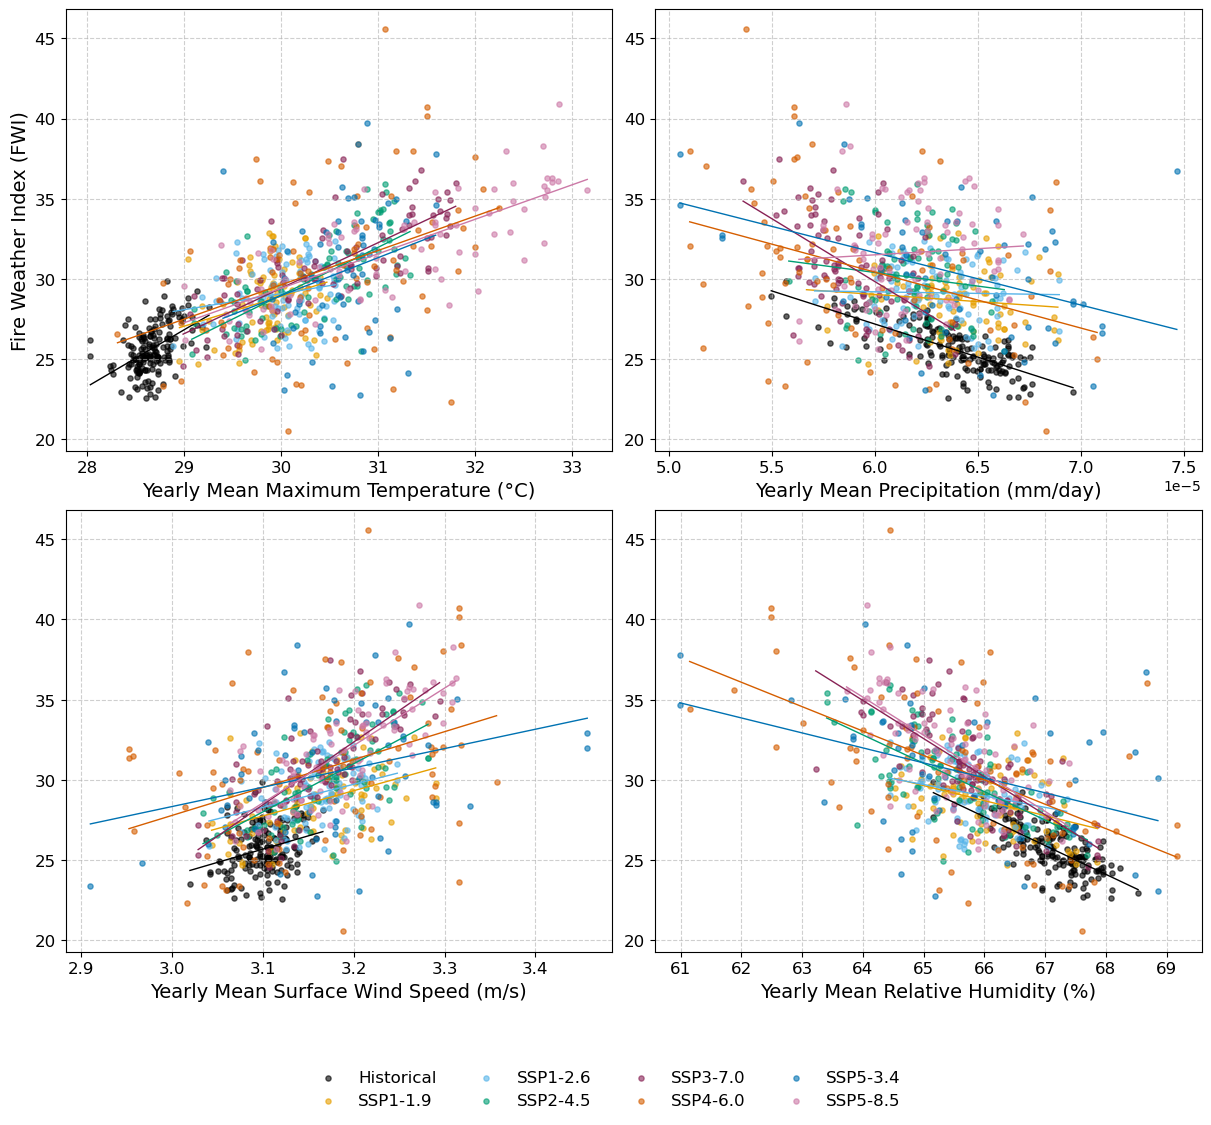

In [147]:
SCENARIO_SHORT = {
    "Historical": "Historical",
    "SSP119": "SSP1-1.9",
    "SSP126": "SSP1-2.6",
    "SSP245": "SSP2-4.5",
    "SSP370": "SSP3-7.0",
    "SSP460": "SSP4-6.0",
    "SSP534": "SSP5-3.4",
    "SSP585": "SSP5-8.5",
}
# ------------------------------------------------------------------------------------------
# PLOTTER — 2×2 GRID VERSION
# ------------------------------------------------------------------------------------------
def plot_fwi_vs_4vars_grid(
    datasets_fwi,
    datasets_tasmax,
    datasets_pr,
    datasets_sfcWind,
    datasets_hursmin,
    labels,
    area_default=None,
    area_map=None,
    title="FWI vs drivers (Thailand)",
    filename="FWI_vs_4drivers_Thailand_grid.png",
    th_slice=dict(lat=slice(5.5,20.5), lon=slice(97.5,105.5))
):
    # area setup
    area_map = area_map or {}
    area_def_da = _area_field(area_default)
    for k in ["tasmax","pr","sfcWind","hursmin"]:
        area_map[k] = _area_field(area_map.get(k, area_def_da))

    # === 2 × 2 subplot grid ===
    fig, axes = plt.subplots(
        nrows=2, ncols=2, figsize=(12,10),
        constrained_layout=True
    )

    panels = [
        dict(name="tasmax",  xlab="Yearly Mean Maximum Temperature (°C)", preferred="tasmax",  series=datasets_tasmax),
        dict(name="pr",      xlab="Yearly Mean Precipitation (mm/day)",   preferred="pr",      series=datasets_pr),
        dict(name="sfcWind", xlab="Yearly Mean Surface Wind Speed (m/s)", preferred="sfcWind", series=datasets_sfcWind),
        dict(name="hursmin", xlab="Yearly Mean Relative Humidity (%)",   preferred="hursmin", series=datasets_hursmin),
    ]

    legend_items = {}

    for ax, panel in zip(axes.flat, panels):
        preferred = panel["preferred"]

        for ds_fwi, ds_x, label_in in zip(datasets_fwi, panel["series"], labels):
            # Y = FWI
            fwi_ts = _region_reduce(_get_da(ds_fwi,"fwisa"), th_slice, area=area_def_da)

            # X variable
            x_ts = _region_reduce(_get_da(ds_x, preferred), th_slice, area=area_map[panel["name"]])

            if "time" in fwi_ts.dims:
                x_ts = _align_to_time(x_ts, fwi_ts["time"])

            x_vals = np.asarray(x_ts.values)
            y_vals = np.asarray(fwi_ts.values)

            m = (~np.isnan(x_vals)) & (~np.isnan(y_vals))
            x_vals, y_vals = x_vals[m], y_vals[m]
            if x_vals.size == 0:
                continue

            key = _scenario_key_from_label(label_in)
            color = color_blind_palette.get(key, "#000000")
            display_label = SCENARIO_SHORT.get(key, label_in)

            # Scatter
            sc = ax.scatter(x_vals, y_vals, color=color, alpha=0.6, s=14)

            # Regression
            slope, intercept, r_val, p_val, std_err = linregress(x_vals, y_vals)
            x_line = np.linspace(np.nanmin(x_vals), np.nanmax(x_vals), 100)
            y_line = slope * x_line + intercept
            ax.plot(x_line, y_line, color=color, linewidth=1.0)

            if key and key not in legend_items:
                legend_items[key] = (sc, display_label)

        ax.set_xlabel(panel["xlab"], fontsize=14)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.tick_params(labelsize=12)

    # Shared Y label (left column)
    axes[0,0].set_ylabel("Fire Weather Index (FWI)", fontsize=14)
    axes[0,1].set_ylabel("")
    axes[1,1].set_ylabel("")

    # Legend
    handles, labels_short = [], []
    for k in SCENARIO_ORDER:
        if k in legend_items:
            h, txt = legend_items[k]
            handles.append(h)
            labels_short.append(txt)

    leg = fig.legend(
        handles, labels_short,
        loc='upper center', bbox_to_anchor=(0.5, -0.05),
        ncol=min(4,len(labels_short)),
        frameon=False, fontsize=12
    )

    plt.subplots_adjust(bottom=0.14)
    plt.savefig(filename, dpi=300, bbox_inches='tight', bbox_extra_artists=[leg])
    plt.show()



# ------------------------------------------------------------------------------------------
# Example Call
# ------------------------------------------------------------------------------------------
labels_tasmax_all_scenarios = [
    'Historical to Present (1850-2015)',
    'SSP1-1.9 ("Sustainability - Very Low Emissions")',
    'SSP1-2.6 ("Sustainability - Low Emissions with Strong Mitigation")',
    'SSP2-4.5 ("Middle of the Road - Moderate Emissions")',
    'SSP3-7.0 ("Regional Rivalry - High Emissions")',
    'SSP4-6.0 ("Inequality - High Emissions")',
    'SSP5-3.4 ("Fossil-Fueled Development - Moderate Emissions")',
    'SSP5-8.5 ("Fossil-Fueled Development - High Emissions, No Climate Policy")'
]

plot_fwi_vs_4vars_grid(
    datasets_fwi=ensemble_means_th_all_scenarios,
    datasets_tasmax=tasmax_means_all_scenarios_th,
    datasets_pr=pr_means_all_scenarios_th,
    datasets_sfcWind=sfcWind_means_all_scenarios_th,
    datasets_hursmin=hursmin_means_all_scenarios_th,
    labels=labels_tasmax_all_scenarios,
    area_default=areacella,
    area_map=None,
    title='FWI vs Key Drivers in Thailand (Annual, Area-weighted)',
    filename='FWI_vs_4drivers_Thailand_grid_2x2_shortlabels.png'
)

C:\Users\asus\AppData\Local\Temp\ipykernel_15908\3822287932.py:113: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(bottom=0.14)


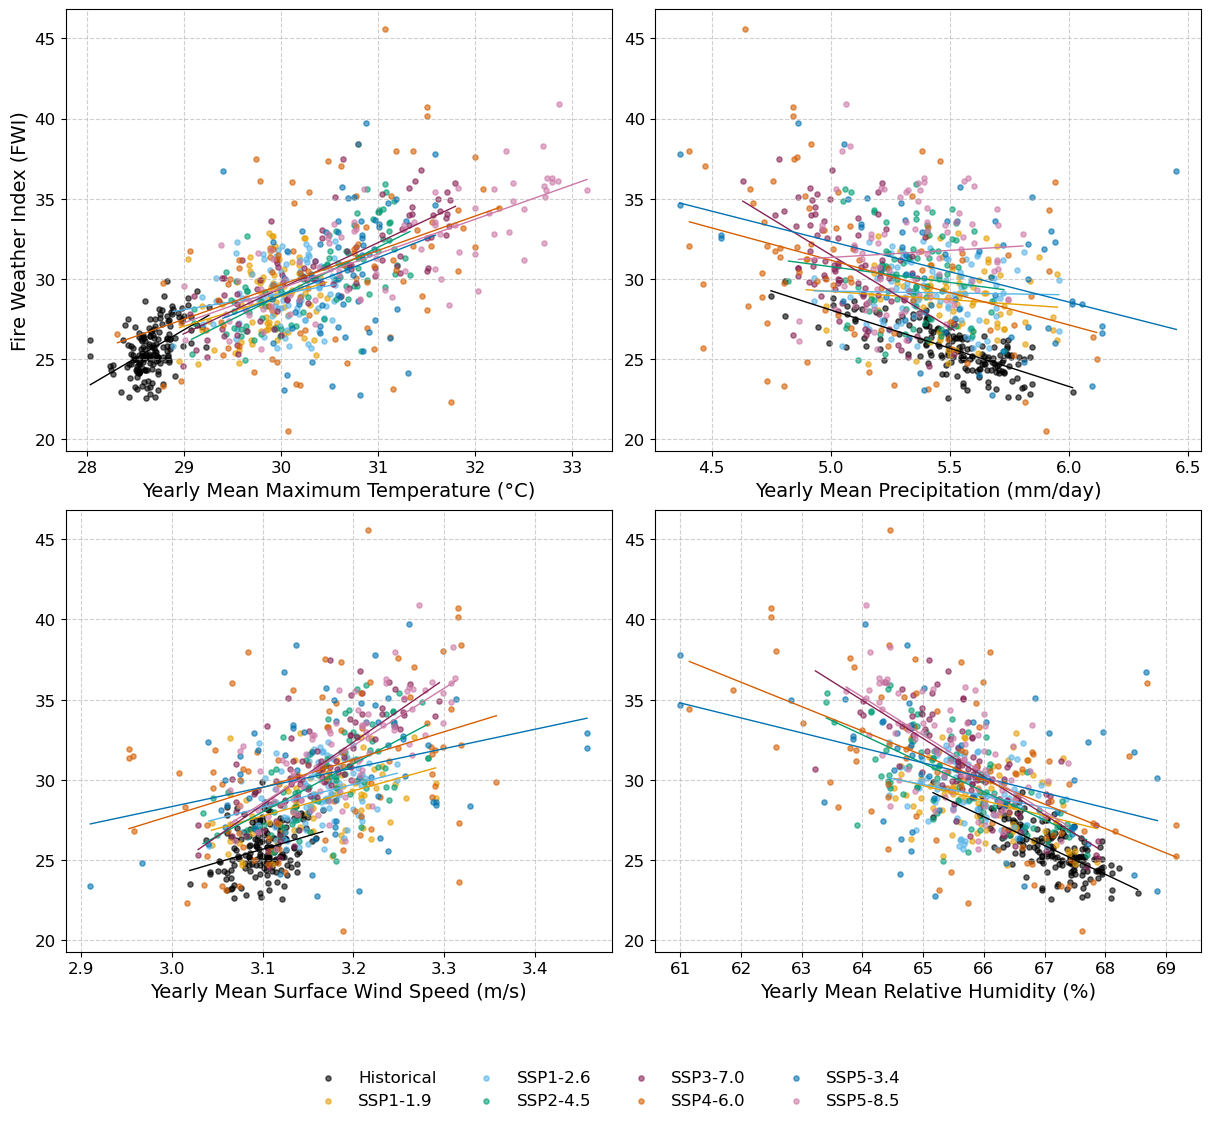

In [148]:
SCENARIO_SHORT = {
    "Historical": "Historical",
    "SSP119": "SSP1-1.9",
    "SSP126": "SSP1-2.6",
    "SSP245": "SSP2-4.5",
    "SSP370": "SSP3-7.0",
    "SSP460": "SSP4-6.0",
    "SSP534": "SSP5-3.4",
    "SSP585": "SSP5-8.5",
}
# ------------------------------------------------------------------------------------------
# PLOTTER — 2×2 GRID VERSION
# ------------------------------------------------------------------------------------------
def plot_fwi_vs_4vars_grid(
    datasets_fwi,
    datasets_tasmax,
    datasets_pr,
    datasets_sfcWind,
    datasets_hursmin,
    labels,
    area_default=None,
    area_map=None,
    title="FWI vs drivers (Thailand)",
    filename="FWI_vs_4drivers_Thailand_grid.png",
    th_slice=dict(lat=slice(5.5,20.5), lon=slice(97.5,105.5))
):
    # area setup
    area_map = area_map or {}
    area_def_da = _area_field(area_default)
    for k in ["tasmax","pr","sfcWind","hursmin"]:
        area_map[k] = _area_field(area_map.get(k, area_def_da))

    # === 2 × 2 subplot grid ===
    fig, axes = plt.subplots(
        nrows=2, ncols=2, figsize=(12,10),
        constrained_layout=True
    )

    panels = [
        dict(name="tasmax",  xlab="Yearly Mean Maximum Temperature (°C)", preferred="tasmax",  series=datasets_tasmax),
        dict(name="pr",      xlab="Yearly Mean Precipitation (mm/day)",   preferred="pr",      series=datasets_pr),
        dict(name="sfcWind", xlab="Yearly Mean Surface Wind Speed (m/s)", preferred="sfcWind", series=datasets_sfcWind),
        dict(name="hursmin", xlab="Yearly Mean Relative Humidity (%)",   preferred="hursmin", series=datasets_hursmin),
    ]

    legend_items = {}

    for ax, panel in zip(axes.flat, panels):
        preferred = panel["preferred"]

        for ds_fwi, ds_x, label_in in zip(datasets_fwi, panel["series"], labels):
            # Y = FWI
            fwi_ts = _region_reduce(_get_da(ds_fwi,"fwisa"), th_slice, area=area_def_da)

            # X variable
            x_ts = _region_reduce(_get_da(ds_x, preferred), th_slice, area=area_map[panel["name"]])

            # Convert precipitation units (kg/m^2/s → mm/day)
            if panel["name"] == "pr":
                x_ts = x_ts * 86400.0

            if "time" in fwi_ts.dims:
                x_ts = _align_to_time(x_ts, fwi_ts["time"])

            x_vals = np.asarray(x_ts.values)
            y_vals = np.asarray(fwi_ts.values)

            m = (~np.isnan(x_vals)) & (~np.isnan(y_vals))
            x_vals, y_vals = x_vals[m], y_vals[m]
            if x_vals.size == 0:
                continue

            key = _scenario_key_from_label(label_in)
            color = color_blind_palette.get(key, "#000000")
            display_label = SCENARIO_SHORT.get(key, label_in)

            # Scatter
            sc = ax.scatter(x_vals, y_vals, color=color, alpha=0.6, s=14)

            # Regression
            slope, intercept, r_val, p_val, std_err = linregress(x_vals, y_vals)
            x_line = np.linspace(np.nanmin(x_vals), np.nanmax(x_vals), 100)
            y_line = slope * x_line + intercept
            ax.plot(x_line, y_line, color=color, linewidth=1.0)

            if key and key not in legend_items:
                legend_items[key] = (sc, display_label)

        ax.set_xlabel(panel["xlab"], fontsize=14)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.tick_params(labelsize=12)

    # Shared Y label (left column)
    axes[0,0].set_ylabel("Fire Weather Index (FWI)", fontsize=14)
    axes[0,1].set_ylabel("")
    axes[1,1].set_ylabel("")

    # Legend
    handles, labels_short = [], []
    for k in SCENARIO_ORDER:
        if k in legend_items:
            h, txt = legend_items[k]
            handles.append(h)
            labels_short.append(txt)

    leg = fig.legend(
        handles, labels_short,
        loc='upper center', bbox_to_anchor=(0.5, -0.05),
        ncol=min(4,len(labels_short)),
        frameon=False, fontsize=12
    )

    plt.subplots_adjust(bottom=0.14)
    plt.savefig(filename, dpi=300, bbox_inches='tight', bbox_extra_artists=[leg])
    plt.show()



# ------------------------------------------------------------------------------------------
# Example Call
# ------------------------------------------------------------------------------------------
labels_tasmax_all_scenarios = [
    'Historical to Present (1850-2015)',
    'SSP1-1.9 ("Sustainability - Very Low Emissions")',
    'SSP1-2.6 ("Sustainability - Low Emissions with Strong Mitigation")',
    'SSP2-4.5 ("Middle of the Road - Moderate Emissions")',
    'SSP3-7.0 ("Regional Rivalry - High Emissions")',
    'SSP4-6.0 ("Inequality - High Emissions")',
    'SSP5-3.4 ("Fossil-Fueled Development - Moderate Emissions")',
    'SSP5-8.5 ("Fossil-Fueled Development - High Emissions, No Climate Policy")'
]

plot_fwi_vs_4vars_grid(
    datasets_fwi=ensemble_means_th_all_scenarios,
    datasets_tasmax=tasmax_means_all_scenarios_th,
    datasets_pr=pr_means_all_scenarios_th,
    datasets_sfcWind=sfcWind_means_all_scenarios_th,
    datasets_hursmin=hursmin_means_all_scenarios_th,
    labels=labels_tasmax_all_scenarios,
    area_default=areacella,
    area_map=None,
    title='FWI vs Key Drivers in Thailand (Annual, Area-weighted)',
    filename='FWI_vs_4drivers_Thailand_grid_2x2_shortlabels.png'
)